In [ ]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# 🌊🛰️ Monitoring Coastal Water Quality and Marine Ecosystem Change Using Satellite Remote Sensing and Machine Learning

**Author**: [Tedi Yankov](https://tediyankov.github.io/), University of Oxford (Intelligent Earth CDT in AI for the Environment), teodor.yankov@new.ox.ac.uk

> *"Remote sensing with satellites is quickly becoming a powerful tool to monitor parameters such as sea surface temperature, turbidity, and levels of chlorophyll-a, enabling ocean warming and harmful algal blooms to be tracked over large regions."*  
> — Callejas, I. (2022). *Nature Reviews Earth & Environment*

This tutorial introduces satellite-based monitoring of coastal water quality and marine ecosystem change using real ocean data from the Copernicus Marine Service and machine learning. Working with three years of daily chlorophyll-a and sea surface temperature observations over the Northern Adriatic Sea, we will explore how harmful algal bloom conditions can be detected from space. We will start with exploratory data analysis through classical ML models (Random Forest, Gradient Boosting), progressing to a patch-based convolutional neural network (CNN) that learns spatial patterns in oceanography data.

This tutorial is based on ongoing research by the author (Tedi Yankov) pending review for publication.

# Overview

## 🌍 Problem: Coastal Ecosystems Under Pressure

Coastal marine ecosystems support fisheries, carbon sequestration (taking carbon out of the atmosphere and storing it in plants, soils, etc), recreation and billions of livelihoods. Yet they are increasingly under stress from:

- **Eutrophication** (when nutrients accumulate in a body of water leading to overgrowth of organisms using up all the oxygen and depleting it from the water) driven by agricultural nutrient runoff and leading to harmful algal blooms (HABs);
- **Ocean warming** resulting in coral bleaching and species range shifts, and further contributing to eutrophication;
- **Increased turbidity** (cloudiness or murkiness of water) from coastal development and storms leading to reduced light penetration and seagrass decline;
- **Extreme weather events** creating intensified storm runoff and stratification changes.

Traditional in-situ water sampling is expensive, slow, and spatially sparse, and is particularly limiting for lower-income countries and remote coastlines. Satellite remote sensing addresses this gap by delivering **daily, global, consistent** measurements of water-leaving radiance, from which water quality parameters are algorithmically derived.

## ❓ Research Questions

This tutorial is framed around a concrete scientific case study in the
**Northern Adriatic Sea**, a region experiencing documented increases in
HAB frequency and intensity under climate change (Marampouti, Buma and
de Boer, 2021; Rubini et al., 2021; Zoffoli et al., 2025). We can ask the following questions:

1. Can physical drivers (sea surface temperature, seasonality,
   and geographic location) predict optical indicators of harmful algal
   bloom conditions in the Northern Adriatic?
2. How do Chl-a, NDCI, and turbidity vary seasonally and spatially, and
   what do their patterns tell us about bloom dynamics?
3. Does incorporating spatial sea surface surface temperature (SST) context via a CNN improve predictions
   over pixel-wise models, for which targets does it help and why?

## 🎯 Learning Objectives

By the end of this tutorial, you will be able to:

1. **Access and query** ocean colour and SST data from the
   [Copernicus Marine Service (CMEMS)](https://marine.copernicus.eu/)
   using the `copernicusmarine` Python toolbox
2. **Understand** the physical meaning of key water quality indicators:
   chlorophyll-a (Chl-a), NDCI, turbidity, and sea surface temperature
3. **Explore** spatiotemporal patterns in coastal water quality using
   `xarray`, `pandas`, `matplotlib`, and `cartopy`
4. **Engineer a feature matrix** from physically independent drivers
   (SST, seasonality, location) and understand why input–target
   independence is important
5. **Train and evaluate** Random Forest and Gradient Boosting models
   across multiple ocean colour targets
6. **Build and train** a spatial CNN that incorporates SST neighbourhood
   context, and critically interpret when spatial deep learning helps
   and when it doesn't
7. **Critically evaluate** model performance.

# Climate Impact

Coastal oceans are on the front line of climate change. Due to rising sea temperatures, HABs grow faster and spread more. On top of this, intensified rainfall events flush larger quantities of agricultural nutrients into coastal waters. This adds additional pressure making bloom events more frequent, more severe, and harder to predict.

This has adverse effects on marine ecosystems. HABs cause a vast array of food web effects across multiple trophic levels by decreasing biodiversity, altering energy flow, causing low oxygen stress (hypoxia or anoxia) from high-biomass blooms, and destroying habitats such as submerged vegetation meadows (Burkholder, Shumway and Glibert, 2018). This creates a profound and lasting effect on marine organisms' growth and toxicity (Fu, Tatters and Hutchins, 2012).

Through consumption of toxic algae, cell surface contact, exposure to toxins in the surrounding water, toxin transfer across trophic levels (bioaccumulation, biomagnification) and consumption of toxin-laced prey (Burkholder, Shumway and Glibert, 2018), these effects enter our food and water systems as well. We see impacts on food security, tourism, local economy, and human health through the closure of fisheries, drinking water contamination and mass fish kills (Gobler, 2020). In lower- and middle-income countries, where coastal fisheries are often a primary protein source and livelihood, the stakes are especially high.

The tools demonstrated in this tutorial sit at the core of real operational systems that are already helping to manage these risks.

* **Who uses these models?** Environmental agencies, port authorities, aquaculture operators, and public health bodies use satellite-derived water quality products daily. [CMEMS](https://marine.copernicus.eu/), whose data we use here, serves tens of thousands of users across Europe - from national environment ministries making bathing water safety decisions to fish farm operators timing harvests to avoid toxin contamination. [NOAA's CoastWatch](https://coastwatch.noaa.gov/cwn/index.html) programme runs equivalent systems for US coastal waters, feeding directly into shellfish harvest closure decisions that protect public health. The UN Sustainable Development Goal 14 (Life Below Water) explicitly calls for satellite-based tools to monitor and restore coastal ecosystem health.

* **What decisions do these models inform?** At the *operational* level: bloom early-warning alerts (giving aquaculture sites 24–72 hours to act), bathing water advisories, and fishery closure triggers. At the *planning* level: identifying chronic eutrophication hotspots to target nutrient reduction policy, tracking whether water quality is improving in response to agricultural regulations, and monitoring the recovery of protected marine areas. Satellite-derived chlorophyll-a maps informed assessments of water quality improvement during the COVID-19 lockdowns (e.g. Flores de Santiago et al., 2025; Sheikholeslami and Ghorbani, 2024). This was a rare natural experiment that demonstrated the direct link between human activity and coastal ecosystem health, including along the Belize coastline documented in Callejas (2022).

* **Why ML matters here specifically?** Classical empirical algorithms (simple band ratios) break down in optically complex coastal waters, where sediment, coloured dissolved organic matter, and algae all influence reflectance simultaneously (Wu et al., 2025). Machine learning models (of exactly the type built in this tutorial) have been shown to significantly outperform these algorithms in turbid nearshore environments (e.g. Chen et al, 2021; Zhang et al., 2026), and are now being integrated into next-generation processing chains for missions like [NASA PACE](https://pace.gsfc.nasa.gov/) (launched 2024), which will deliver hyperspectral ocean colour data at unprecedented spectral resolution. Companies such as [EOMAP](https://eomap.com/) and [OceanMind](https://oceanmind.global/) are already deploying ML-based satellite water quality products commercially for port operators and fisheries enforcement.

Every hour of advance warning before a bloom peaks is time for an aquaculture operator to move stock, for a water utility to switch intake, or for a fisheries authority to issue a closure notice. Scaled across coastlines where in-situ monitoring is sparse or unaffordable (ie much of Southeast Asia, West Africa, and Latin America) satellite ML pipelines may represent the only viable monitoring system. Getting these models right, and making the tools to build them accessible, is therefore not just a technical exercise but a contribution to climate adaptation infrastructure for some of the world's most vulnerable coastal communities.

# Background

## 🌿 Harmful Algal Blooms and Ocean Colour Indicators

**Harmful Algal Blooms (HABs)** occur when phytoplankton (the the microscopic
algae that form the base of the marine food web) multiply explosively and reach concentrations that are damaging to ecosystems and health.

HABs can deplete oxygen in the water column (creating "dead zones"), produce toxins that accumulate in shellfish and fish, and cause mass mortality of marine
fauna.

In the Northern Adriatic, HABs are closely tied to nutrient
discharge from the Po River (the largest river in Italy) which flushes
nitrogen and phosphorus into the sea, accelerating phytoplankton growth
particularly during spring.

Climate change is making HABs worse: warmer sea temperatures speed up
phytoplankton growth rates and extend bloom seasons, while more intense
rainfall delivers larger nutrient pulses to coastal waters. A colour-enhanced visualisation of an algal bloom can be seen in the picture below:

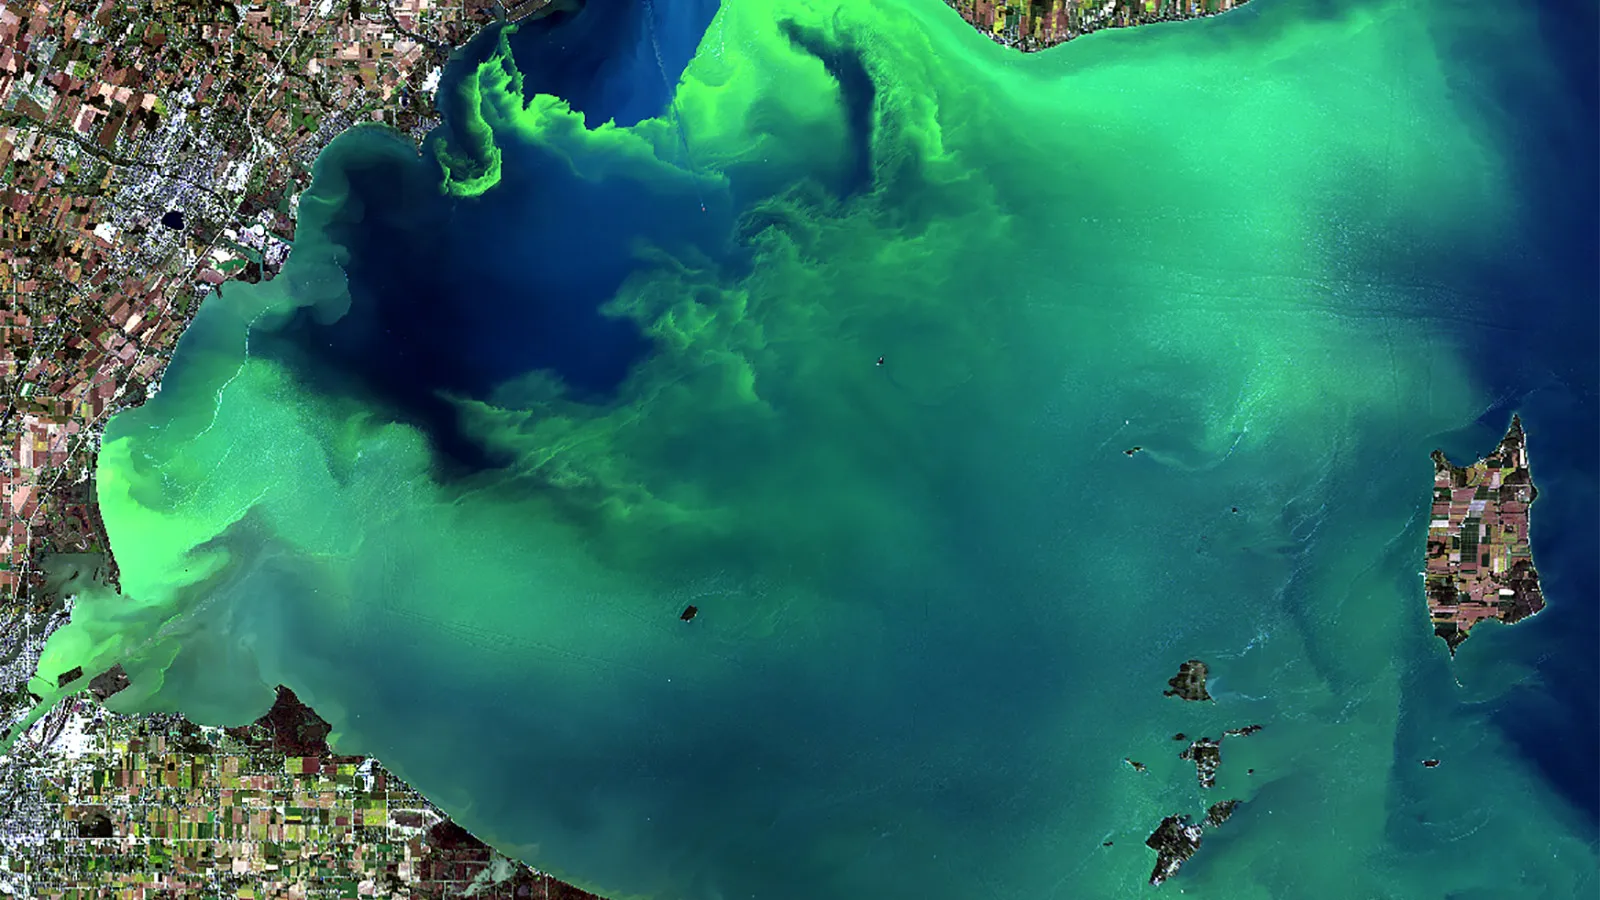

We track HAB conditions using three complementary optical indicators,
each measurable using satellite remote sensing:

### Chlorophyll-a (Chl-a)

Chlorophyll-a is the primary photosynthetic pigment in phytoplankton.
Its concentration in the water (measured in mg m⁻³) is the most direct
satellite-accessible measure of phytoplankton biomass. As bloom
conditions develop, chl-a rises.

Satellites detect this by measuring the colour of the ocean: bloom-affected water appears greener than healthy open-ocean water because
phytoplankton absorb blue light and reflect green.

We predict **log₁₀(Chl-a)** - the log transform is applied because
Chl-a is log-normally distributed.

### Normalised Difference Chlorophyll Index (NDCI)

Before defining NDCI, it helps to understand the notation. When a
satellite measures ocean colour, it records the intensity of light
leaving the water surface across multiple **wavelength bands** ie
specific slices of the electromagnetic spectrum measured in nanometres
(nm). We write the reflectance at a given wavelength $\lambda$ as
$R_{rs}(\lambda)$, where **Rrs** stands for *remote sensing
reflectance* (in units of sr⁻¹). So $R_{rs}(555)$ means "the
reflectance measured at 555 nm" which is the green part of the visible
spectrum.

The two wavelengths used in NDCI are chosen for a specific physical
reason:

- **$R_{rs}(555)$ - green (555 nm):** Chlorophyll-a *reflects* green
  light. As phytoplankton biomass increases, green reflectance rises,
  making this band sensitive to the presence of algae.
- **$R_{rs}(670)$ - red (670 nm):** Chlorophyll-a *absorbs* red light. As biomass increases, red reflectance decreases, which is the
  opposite behaviour to green. This contrast between the two bands is
  what NDCI exploits.

NDCI is a **classical spectral index** - a simple hand-crafted formula
that combines these two bands to produce a single number sensitive to
chlorophyll concentration. It predates machine learning and remains
widely used in operational ocean colour monitoring today:

$\displaystyle \text{NDCI} = \frac{R_{rs}(670) - R_{rs}(555)}{R_{rs}(670) + R_{rs}(555)}$

Dividing by the sum keeps values bounded between
−1 and +1 and makes the index robust to variations in overall light
intensity. As phytoplankton biomass rises, $R_{rs}(670)$ falls and
$R_{rs}(555)$ rises, pushing NDCI toward more negative values. This
is why our dataset shows NDCI concentrated between −1 and 0.

NDCI is particularly valuable in **turbid nearshore waters** near river
mouths where the classical blue/green ratio algorithms (like OC3) break
down. Suspended sediment and coloured dissolved organic matter interfere with the blue and green bands, but the red band used in NDCI
is less affected by these confounders.

### Turbidity

Turbidity measures how much suspended matter scatters light in the water
column. In the Northern Adriatic, high turbidity often precedes and
accompanies HABs: Po River discharge delivers both nutrients (which fuel
bloom growth) and suspended sediment (which increases turbidity). Turbidity
therefore functions as an indicator of the physical preconditions for
bloom development.

We compute turbidity as a proxy from the ratio of red to blue-green
reflectance:

$$\text{Turbidity proxy} = \frac{R_{rs}(670)}{R_{rs}(490)}$$

This ratio increases when suspended sediment and organic particles
scatter red light more strongly relative to blue-green. We apply a
log₁₀ transform to handle the right-skewed distribution driven by
episodic river discharge events.

Together, these three indicators capture different dimensions of the
same ecosystem state: biomass (chl-a), optical bloom signal (NDCI),
and physical water clarity (turbidity). This gives a more complete picture
of HAB conditions.

## 🛰️ Satellite observation chain

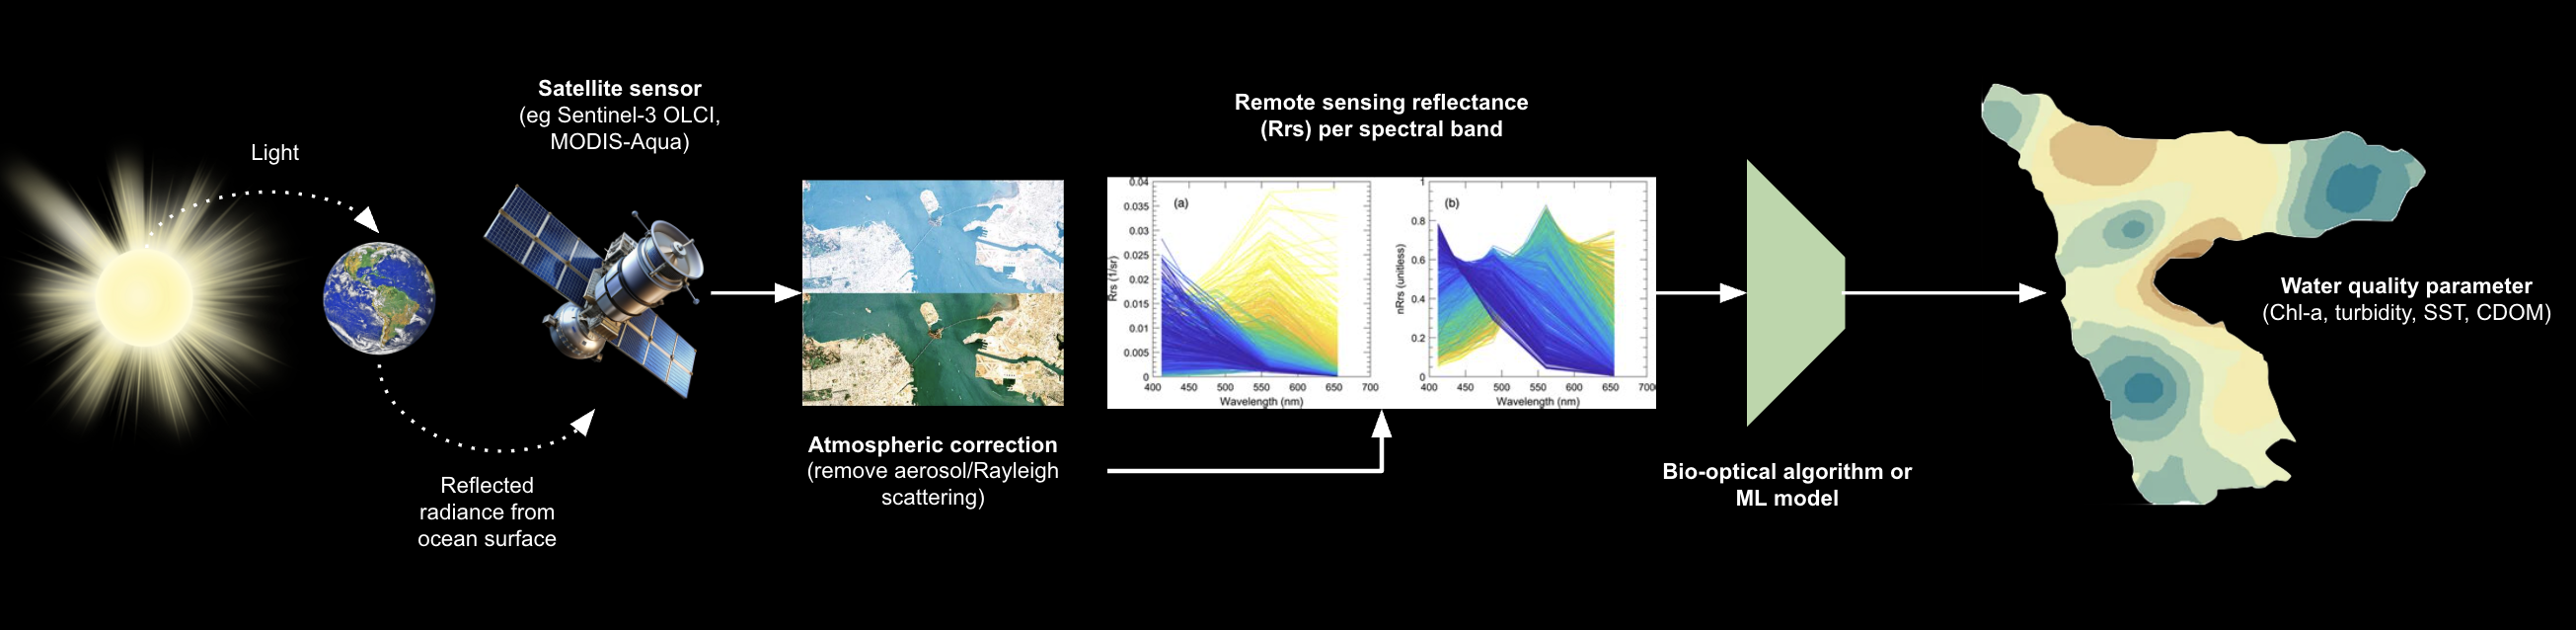

The figure above summarises how we end up with satellite measurements of parameters like Chl-a. The light coming from the sun and reflected off of our oceans is received by a satellite sensor. The received signal needs to be processed before it's used downstream, so it goes through a process called atmospheric correction via which various light scattering effects are accounted for (it works like a filter). Then, we look at the remote sensing reflectances of the different spectral bands present in the reflected light. This acts like a fingerprint of the water’s composition—revealing details such as the presence of algae, sediment, or dissolved organic matter. This signal is then given to either a bio-optical algorithm or an ML model, which translates the signal into an interpretable value measurement such as Chl-a, turbidity, SST or Colored Dissolved Organic Matter (CDOM).

Some key satellite platforms are the following:

| Satellite | Sensor | Spatial Res. | Revisit | Key Use |
|-----------|--------|-------------|---------|--------|
| Sentinel-3A/B | OLCI | 300 m | ~1–2 days | Ocean colour, Chl-a, HABs |
| Terra/Aqua | MODIS | 250–1000 m | Daily | SST, global Chl-a |
| Sentinel-2A/B | MSI | 10–60 m | 5 days | Coastal/nearshore detail |
| Landsat 8/9 | OLI+TIRS | 30 m | 16 days | Coastal, SST |
| NASA PACE | OCI | ~1 km | Daily | Hyperspectral ocean colour (2024+) |

In this tutorial we use **pre-processed Level-4 CMEMS products** (gap-filled, quality-controlled) derived from multiple sensors including Sentinel-3 OLCI.

## 🌈 Classical approach

The simplest way to estimate Chl-a from a satellite is a band ratio. For example, dividing the reflectance measured in the blue part of the spectrum by the reflectance in the green part. As Chl-a increases, this ratio decreases predictably, and a lookup table or simple equation converts it to a concentration. These empirical algorithms are fast, transparent, and still widely used in open-ocean settings.

The problem is that coastal waters are optically complex. Sediment stirred up from the seafloor, coloured organic matter from rivers, and algae all affect the colour of the water simultaneously. This makes simple band ratios unreliable.


## 🤖 Machine Learning algorithms

Rather than relying on a single hand-crafted equation, an ML model learns the relationship between multiple variables and Chl-a directly from data, capturing non-linear interactions that empirical formulas miss.

In this tutorial, we will move through three different ML models of increasing complexity - Random Forest, Gradient Boosting, and a Convolutional Neural Network (CNN). The specifics of these models and how they work are explained above the relevant code in this notebook.


## ✨ Tutorial pre-requisites

This tutorial should be accessible to anyone with at least a basic understanding of AI/ML and climate and oceanography, as well as a basic to intermediate command of Python. Relevant concepts are explained throughout, with sign-posting to resources I personally found useful when learning about these concepts.

In terms of actually running the code in the tutorial - running on GPU (T4 of better) is recommended. GPU acceleration is useful here because it speeds up training and evaluation considerably, and without it, the computations run way slower.

Running it within Google Colab is best, as this is what the tutorial was written for, however a `requirements.txt` is provided for those who wish to run things locally in their own virtual environments.

# Software requirements

To start off, we install the `copernicusmarine` toolbox, along with geospatial and deep learning dependencies.

❗ **Important**: run the cell below twice (the first run it will say session crashed, just re-run it as soon as that happens). If not working, go to the top navigation bar and click `Runtime -> Restart session`.

> 📌 **Note**: Seeing `ERROR: pip's dependency resolver does not currently take into account all the packages that are installed` is normal with Colab, because many packages are pre-installed. When you uninstall and then reinstall core libraries like numpy or scipy, pip detects that other pre-installed packages might become incompatible. It's warning you about the potential for other things to break.



In [ ]:
## installing dependencies
# this set up is because of Colab dependency issues due to pre-installed packafes.
# run this cell once and then the kernel will restart automatically.
# after restart, run this cell again and it will skip installation and show ✅
# this means you can proceed to the next cell which imports libraries

import subprocess, sys, os

# helper function for package install
def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

try:
    import copernicusmarine, sklearn, cmocean, cartopy, torch
    print("✅ All packages installed! Safe to proceed to the imports cell.")

except ImportError:
    print("📦 Installing packages... kernel will restart once when complete.")

    pip("numpy==1.26.4")
    pip("scipy==1.13.1")
    pip("scikit-learn==1.4.2")
    pip("copernicusmarine")
    pip("xarray")
    pip("netCDF4")
    pip("cmocean")
    pip("cartopy")
    pip("seaborn")
    pip("codecarbon")
    pip("torch", "torchvision", "--index-url", "https://download.pytorch.org/whl/cu118")

    print("✅ Installation complete! restarting kernel now...")
    os.kill(os.getpid(), 9)

Once this is done, we can do our main library imports using the cell below:



> 📌 **Note**: if this fails with an error, navigate to the tool bar at the top and go `Runtime -> Restart Session`. After doing that, re-run the [cell above](https://colab.research.google.com/drive/1qlKw4vZ1pdxc8zxhPaOiAaRFHwJV5fgP#scrollTo=Cz6yDDeShzu8&line=1&uniqifier=1) and then run the library imports cell again. It should then work. You *might* have to do this a couple times...



In [ ]:
## library imports
import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import copernicusmarine
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

In [ ]:
# estimating the CO₂ emissions of this notebook with CodeCarbon

from codecarbon import EmissionsTracker

tracker = EmissionsTracker(
    project_name = "coastal-water-quality-tutorial",
    experiment_id = "ccai-summer-school-2025",
    measure_power_secs = 15,
    save_to_file = False,
    log_level = "error"
)
tracker.start()
print("🌱 Carbon tracking started")

The last thing to do at this stage is to set our dervice to GPU. When we do this, we can basically send parts of our ML code to run on GPU to accelerate the process. To do this, navigate to the toolbar at the top of the page and go `Edit -> Notebook settings -> Hardware accelerator -> if CPU is selected, unselect it and select T4 GPU -> Click Save`

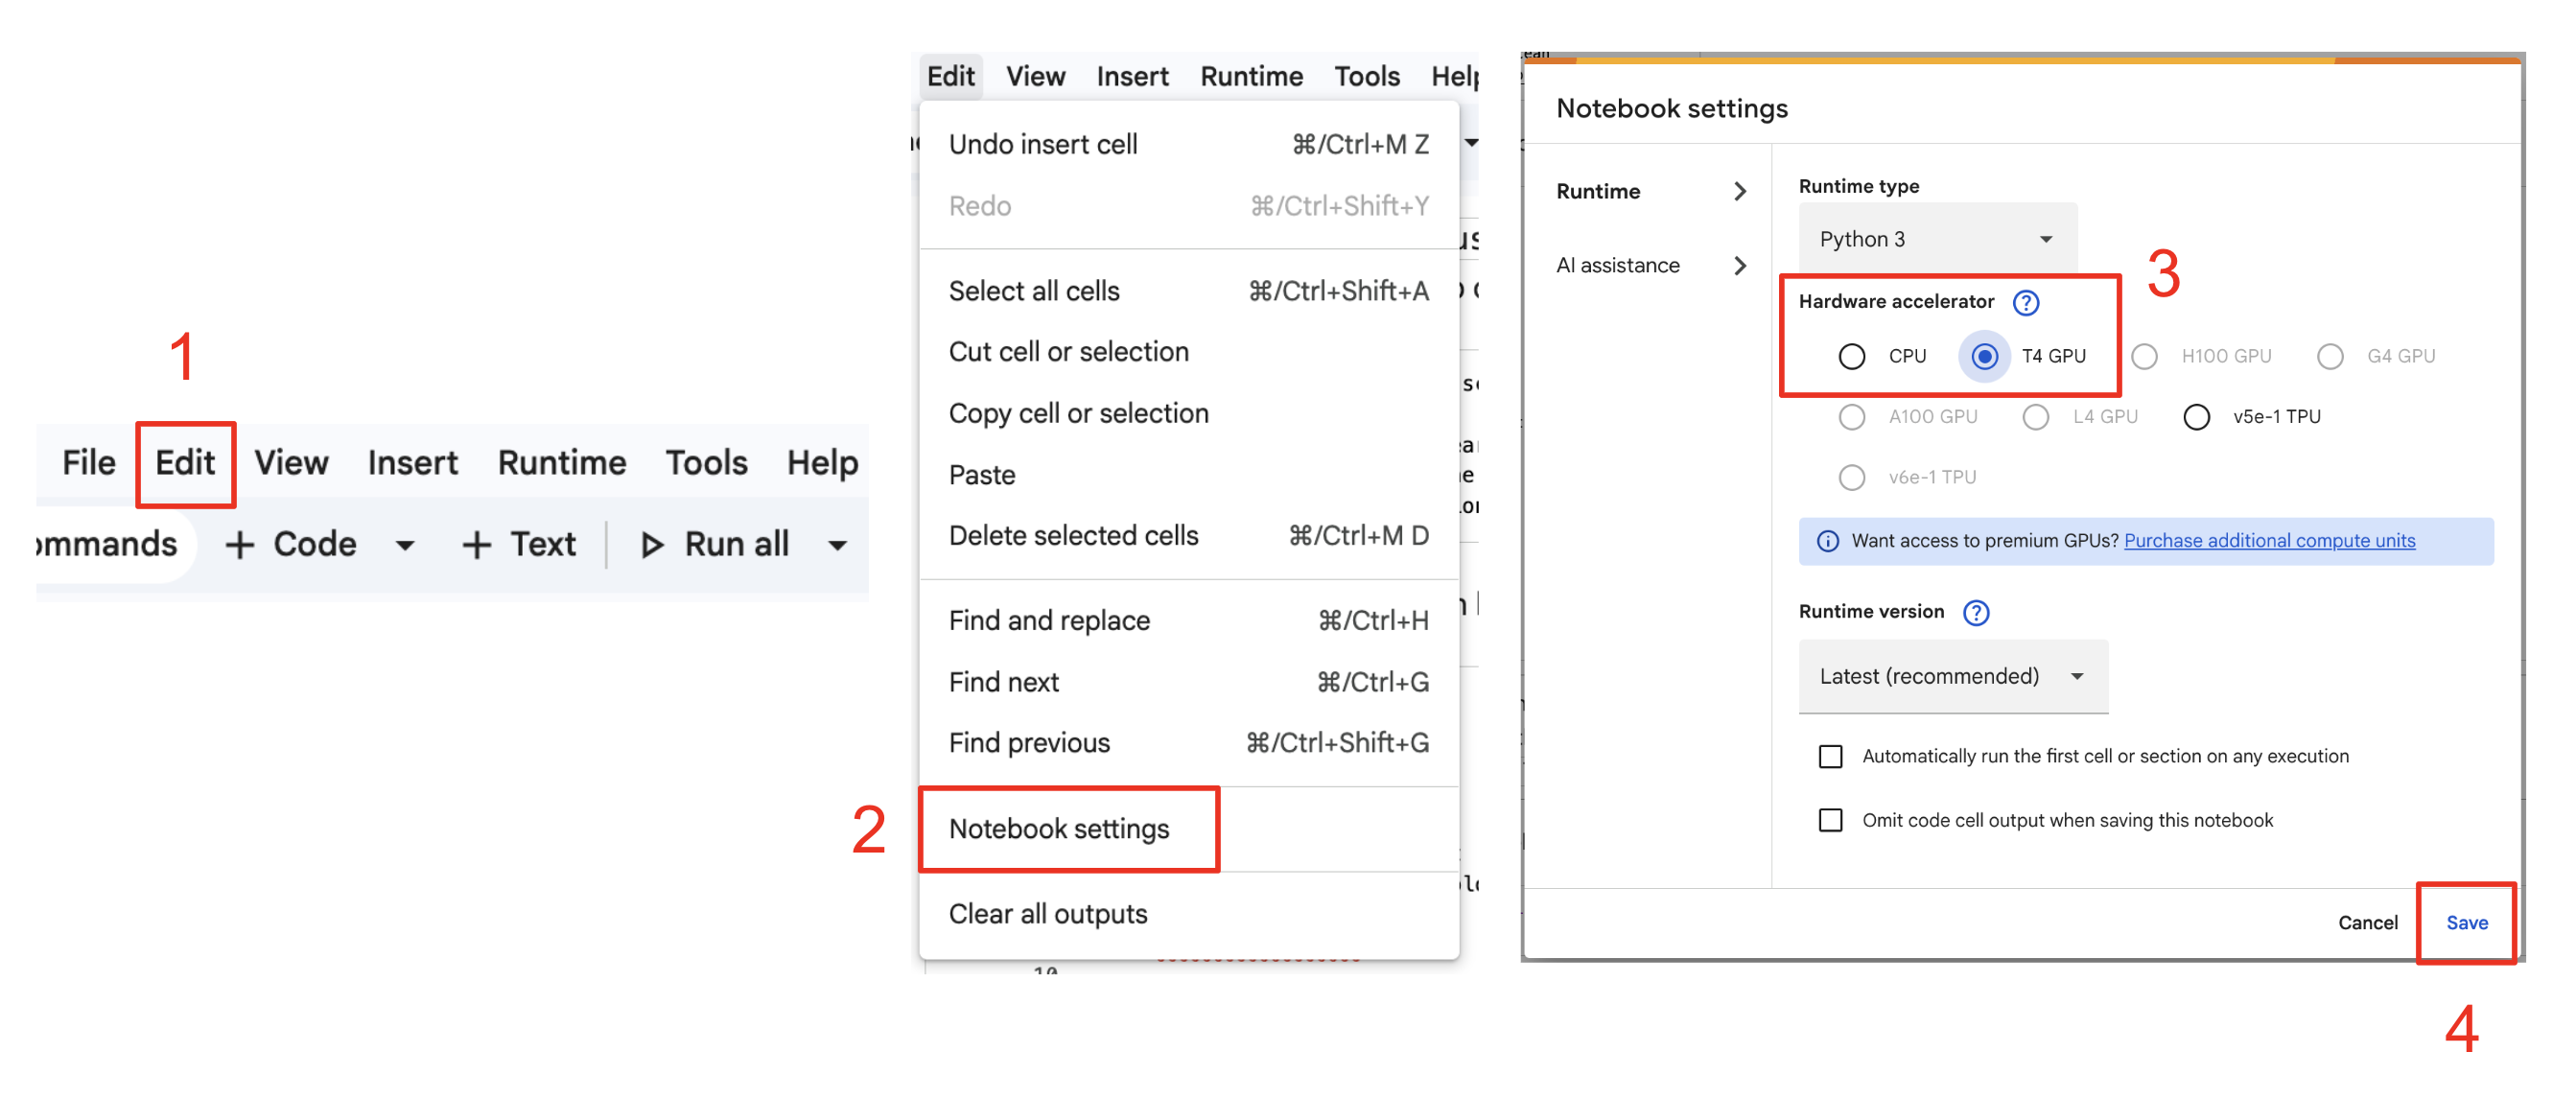

This might restart your session, in which case you'll need to run the cells above again. After all this, if you see `🖥️  Using device: cuda` when you run the cell below, we're good!

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {device}")

# Data

## 📖 Data description

All data in this tutorial comes from the **[Copernicus Marine Service (CMEMS)](https://marine.copernicus.eu/)**. The CMEMS is the ocean component of the
European Union's Copernicus Earth observation programme. It provides free,
open-access data products covering the global ocean and European regional
seas, including physical variables (temperature, salinity, currents, sea
level) and biogeochemical variables (chl-a, oxygen, nutrients,
carbon).

Products are derived from a combination of satellite observations, in-situ
measurements (floats, moorings, ships), and ocean model simulations. Data
goes through rigorous quality control and is made available at multiple
processing levels:

| Level | Description |
|-------|-------------|
| **L3** | Satellite observations mapped to a regular grid, with clouds masked but gaps remaining |
| **L4** | Gap-filled using interpolation or model fusion (ie the cleanestr most analysis ready product) |

We use:
- **`OCEANCOLOUR_MED_BGC_L4_MY_009_144`**: Mediterranean Sea, multi-year, Level-4 daily/monthly Chl-a at 4 km resolution (ocean colour)
- **`SST_MED_SST_L4_REP_OBSERVATIONS_010_021`**: Mediterranean Sea Surface Temperature, 0.05° resolution

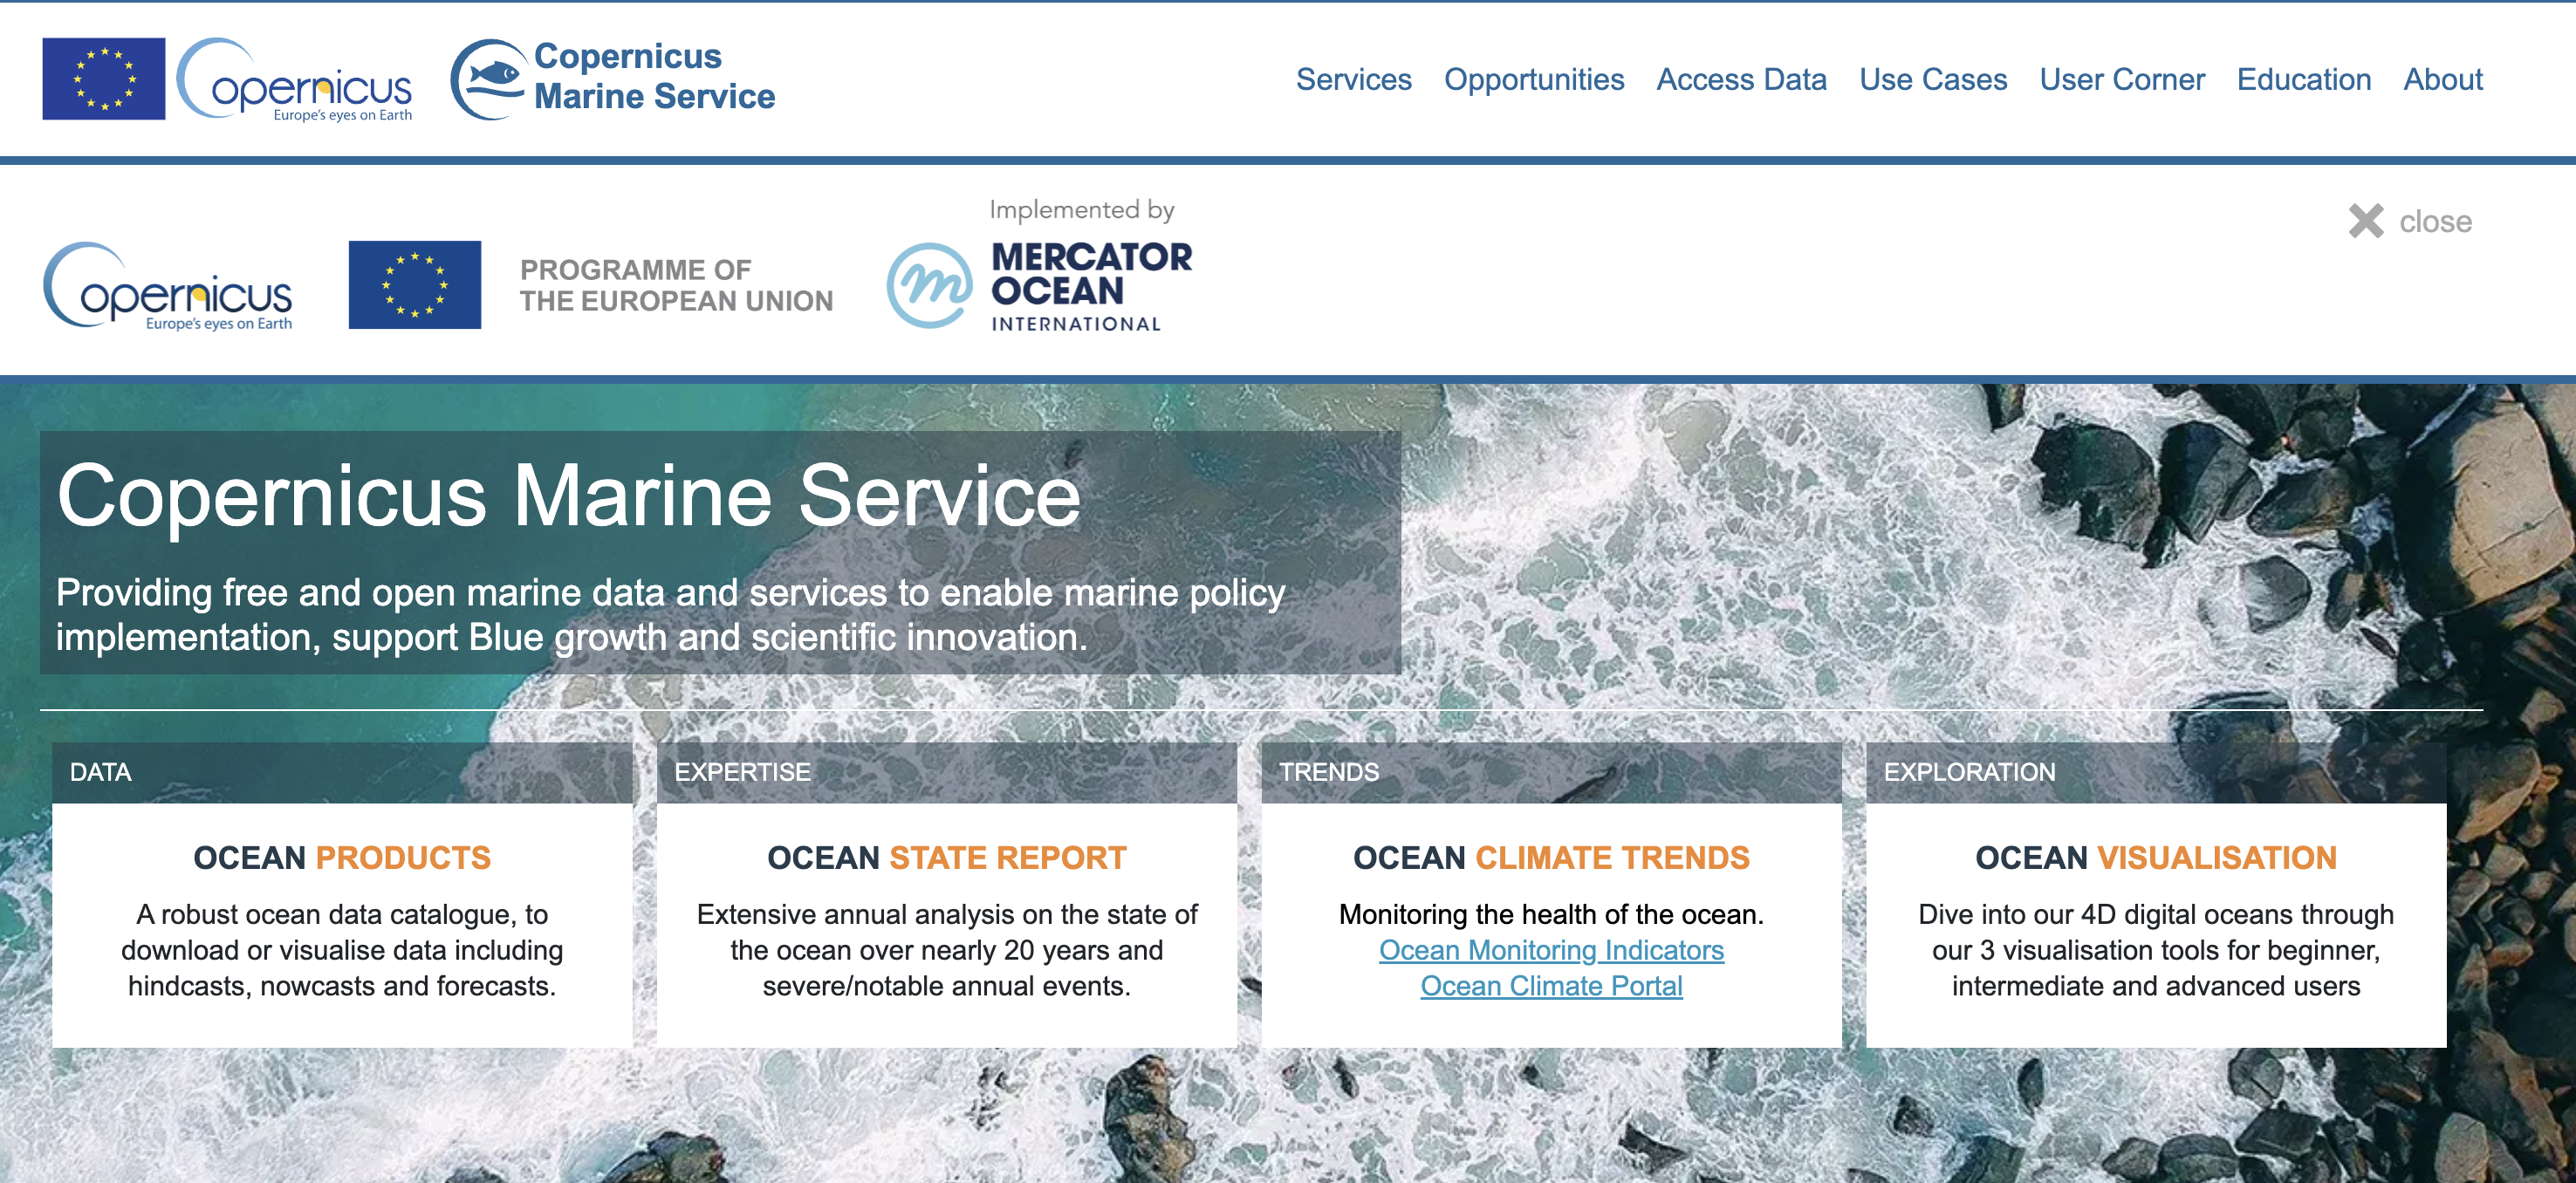

The table below summarises the variables we download and use throughout
the tutorial.

| Variable | Full Name | Units | CMEMS Product ID | Spatial Res. | Temporal Res. | Role |
|----------|-----------|-------|-----------------|-------------|--------------|------|
| `CHL` | Chlorophyll-a concentration | mg m⁻³ | `cmems_obs-oc_med_bgc-plankton_my_l4-gapfree-multi-1km_P1D` | 1 km | Daily | EDA + target derivation |
| `analysed_sst` | Sea Surface Temperature | K (→ °C) | `cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021` | ~5 km | Daily | **Model input** |
| `RRS412–670` | Remote sensing reflectance (5 bands) | sr⁻¹ | `cmems_obs-oc_med_bgc-reflectance_my_l3-multi-1km_P1D` | 1 km | Daily | Target derivation |

From these downloaded variables we derive the following during preprocessing:

| Derived variable | Formula | Physical meaning | Role |
|-----------------|---------|-----------------|------|
| `log_chl` | log₁₀(CHL) | Log-transformed Chl-a; compresses lognormal distribution | **Target** |
| `ndci` | (RRS670 − RRS555) / (RRS670 + RRS555) | Normalised Difference Chlorophyll Index | **Target** |
| `log_turb` | log₁₀(RRS670 / RRS490) | Log turbidity proxy; red/blue ratio | **Target** |
| `sin_month` | sin(2π × month / 12) | Circular seasonal encoding | **Input** |
| `cos_month` | cos(2π × month / 12) | Circular seasonal encoding | **Input** |
| `lat`, `lon` | Pixel coordinates | Geographic location | **Input** |

> **📌 Why this input–target split?** SST comes from thermal infrared
> sensors ie a completely separate measurement chain from the ocean colour
> retrieval that produced Chl-a, NDCI, and turbidity. This means our
> inputs and targets are physically independent, avoiding a circularity
> problem that arises when ocean colour bands are used as both inputs and
> targets.

## ⬇️ Data download

To download the data, you must first register a CMEMS account [here](https://marine.copernicus.eu/). The process is easy and free! Once you have your credentials, you need to save them as Colab secrets. This is the Google Colab equivalent of setting an environmental variable on your local machine. We do this so that we can share code without leaking our private credentials.

Follow these steps to add your CMEMS credentials as Colab secrets:

1. Click the 🔑 key icon in the left sidebar of Colab
2. Click "Add new secret"
3. In the Name field type: `CMEMS_USERNAME`
4. In the Value field type: your actual CMEMS username (e.g. john.smith@email.com)
5. Toggle "Notebook access" to ON
6. Repeat for `CMEMS_PASSWORD` with your actual password

Once this is done, run the cell below and follow the prompts it gives you:

In [ ]:
cmems_user, cmems_pass = '', ''

try:
    from google.colab import userdata
    cmems_user = userdata.get('CMEMS_USERNAME')
    cmems_pass = userdata.get('CMEMS_PASSWORD')
    print(f"✅ Credentials loaded from Colab Secrets for user: {cmems_user}")
except Exception:
    # if you're running this locally and not on Colab, this logic lets you run the
    # authentication provided you've saved your credentials as environmental vars
    # called COPERNICUSMARINE_SERVICE_USERNAME and COPERNICUSMARINE_SERVICE_PASSWORD
    cmems_user = os.environ.get('COPERNICUSMARINE_SERVICE_USERNAME', '')
    cmems_pass = os.environ.get('COPERNICUSMARINE_SERVICE_PASSWORD', '')
    if cmems_user:
        print(f"✅ Credentials loaded from environment variables for user: {cmems_user}")
    else:
        print("⚠️  No credentials found -> you will be prompted to enter them below.")

copernicusmarine.login(username=cmems_user or None, password=cmems_pass or None)

If the last line of the above output is correct, then you're all set!

### Downloading Mediterranean ocean colour and SST data

We download three datasets covering the **Northern Adriatic Sea**
(2019–2022) - one of Europe's most eutrophication-prone coastal seas,
with well-documented spring HABs driven by Po River nutrient discharge.

- **L4 Chl-a**: gap-filled daily maps used for EDA and deriving the
  `log_chl` target
- **L4 SST**: thermal infrared sea surface temperature, acting as our primary
  model input
- **L3 Rrs**: cloud-masked reflectance bands used to derive the `ndci`
  and `log_turb` targets

> **📌 L3 vs L4:** The L4 Chl-a product is gap-filled (clouds removed
> by interpolation). The L3 Rrs product retains cloud gaps as NaNs,
> meaning `ndci` and `log_turb` targets are only available on clear-sky days.

**Bounding box:** (ie the slice of map relevant to our region)
```
Longitude: 12.0°E – 15.5°E
Latitude: 43.5°N – 45.8°N
```

In [ ]:
## setting the study region: Northern Adriatic Sea
STUDY_REGION = dict(
    minimum_longitude = 12.0,
    maximum_longitude = 15.5,
    minimum_latitude = 43.5,
    maximum_latitude = 45.8,
    start_datetime = "2019-01-01",
    end_datetime = "2022-12-31",
)

In [ ]:
## downloading CHL-A product from CEMS
# product: OCEANCOLOUR_MED_BGC_L4_MY_009_144
# dataset: Plankton, multi-sensor, 1 km gap-free, daily
# catalogue to confirm names: https://data.marine.copernicus.eu/product/OCEANCOLOUR_MED_BGC_L4_MY_009_144
import os
os.makedirs("data", exist_ok=True)

chl_response = copernicusmarine.subset(
    dataset_id = "cmems_obs-oc_med_bgc-plankton_my_l4-gapfree-multi-1km_P1D",
    variables  = ["CHL"],
    output_filename   = "med_chl_adriatic_2019_2022.nc",
    output_directory  = "data",
    **STUDY_REGION
)

In [ ]:
## downloading SST L4 product
# product: SST_MED_SST_L4_REP_OBSERVATIONS_010_021
# dataset: cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021
# daily nighttime optimally interpolated foundation SST at 0.05° resolution

sst_response = copernicusmarine.subset(
    dataset_id = "cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021",
    variables = ["analysed_sst"],
    output_filename = "med_sst_adriatic_2019_2022.nc",
    output_directory = "data",
    **STUDY_REGION
)

In [ ]:
## downloading real L3 Rrs reflectance bands
# dataset: cmems_obs-oc_med_bgc-reflectance_my_l3-multi-1km_P1D
# multi-sensor merged (SeaWiFS, MODIS, MERIS, VIIRS, OLCI-S3A/B)
# this is atmospherically corrected water-leaving reflectance (sr⁻¹)
# NOT gap-filled ie cloud/quality masked pixels are NaN intentioanlly
# note: this will take a while to run.

rrs_response = copernicusmarine.subset(
    dataset_id = "cmems_obs-oc_med_bgc-reflectance_my_l3-multi-1km_P1D",
    variables = ["RRS412", "RRS443", "RRS490", "RRS555", "RRS670"],
    output_filename  = "med_rrs_adriatic_2019_2022.nc",
    output_directory = "data",
    **STUDY_REGION
)

## 🌍 Exploratory data analysis

In [ ]:
## loading datasets with xarray
ds_chl = xr.open_dataset("data/med_chl_adriatic_2019_2022.nc")
ds_sst = xr.open_dataset("data/med_sst_adriatic_2019_2022.nc")
ds_rrs = xr.open_dataset("data/med_rrs_adriatic_2019_2022.nc")

chl = ds_chl['CHL']
sst = ds_sst['analysed_sst'] - 273.15   # Kelvin → Celsius

print("L4 Chl-a")
print(f"Shape: {chl.shape} (time × lat × lon)")
print(f"Range: {float(chl.min()):.3f} – {float(chl.max()):.3f} mg m⁻³")
print(f"NaN: {float(chl.isnull().mean())*100:.1f}%")

print("\nSST")
print(f"Shape: {sst.shape}")
print(f"Range: {float(sst.min()):.1f} - {float(sst.max()):.1f} °C")

print("\nL3 Rrs")
print(f"Shape: {ds_rrs['RRS490'].shape}")
print(f"NaN (RRS490): {float(ds_rrs['RRS490'].isnull().mean())*100:.1f}%")
print("(high NaN% is expected - L3 is cloud-masked, not gap-filled)")

**xarray 101:** an `xr.Dataset` stores N-dimensional labelled arrays
(called `DataArrays`). Our datasets have dimensions
`(time, latitude, longitude)`. We can slice, aggregate, and plot along
any dimension using intuitive labels.

**Key variables:**
- `CHL`: chlorophyll-a in mg m⁻³ (log-normally distributed, used for
  EDA and as one of three prediction targets)
- `analysed_sst`: sea surface temperature in Kelvin (our primary model input)
- `RRS412–670`: water-leaving reflectance in sr⁻¹ at five wavelengths
  (used to derive NDCI and turbidity targets, L3 so cloud-masked)
- Valid Chl-a range: ~0.01 (clear oligotrophic) to ~50 mg m⁻³ (bloom)

Next, we inspect our data to find out more about its structure:

In [ ]:
## data inspection
chl = ds_chl['CHL']
sst = ds_sst['analysed_sst'] - 273.15  # here we convert SST from Kelvin to Celsius

## printing shape and time range for chl-a
print(f"Chl-a shape: {chl.shape}  (time × lat × lon)")
print(f"Time range: {str(chl.time.values[0])[:10]} → {str(chl.time.values[-1])[:10]}")
print(f"Spatial res: {abs(float(chl.longitude[1]-chl.longitude[0])):.4f}°")

## calculating and printing statistical summary
print(f"\nChl-a statistics (mg m⁻³):")
print(f"Mean: {float(chl.mean()):.3f}")
print(f"Median: {float(chl.median()):.3f}")
print(f"Max: {float(chl.max()):.3f}")
print(f"NaN fraction: {float(chl.isnull().mean())*100:.1f}%")

> **📊 Reading the output:** our dataset contains 1,461 daily snapshots
> (4 years × ~365 days) across a 227 × 272 pixel grid at ~1.3 km
> resolution. This is fine enough to resolve river plume structure near the Po
> Delta. The large gap between mean (0.62 mg m⁻³) and median
> (0.26 mg m⁻³) confirms the strongly skewed log-normal distribution
> typical of ocean chl-a: most of the sea is oligotrophic most of the
> time, but occasional high-biomass bloom events pull the mean upward. This is why we apply a log₁₀ transform when using Chl-a as a
> prediction target. The 43% NaN fraction reflects land, cloud, and
> quality-flagged pixels.

### Getting a single snapshot daily chl-a map

A great way to check whether our data makes sense is to plot a daily snapshot. If the data looks okay for a small sample of days, then we know we've done a good job so far.

In [ ]:
## choosing specific days to visualise chl-a distribution
bloom_day = "2020-04-15"
winter_day = "2020-01-15"

## creating fig with 2 subplots, each using a platecarree projection for geographical data
fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                          subplot_kw={'projection': ccrs.PlateCarree()})

## iterating through the chosen days and corresponding subplots
for ax, day, title in zip(axes, [bloom_day, winter_day],
                           [f'Spring (bloom season)\n{bloom_day}',
                            f'Winter (low biomass)\n{winter_day}']):
    # selecting the chl-a data for the specific day
    snapshot = chl.sel(time=day, method='nearest')

    # log-transforming chl-a
    log_chl = np.log10(snapshot.where(snapshot > 0))

    # ploting the log-transformed chl-a using pcolormesh
    im = ax.pcolormesh(snapshot.longitude, snapshot.latitude, log_chl,
                       cmap=cmocean.cm.algae, vmin=-1, vmax=1.5,
                       transform=ccrs.PlateCarree())

    # adding land features and coastline for geographical context
    ax.add_feature(cfeature.LAND, facecolor='#d9c9a3')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

    # adding gridlines and removing labels (this is a design preference, you can play around with it)
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10, fontweight='bold')

    # adding a colorbar to indicate chl-a values
    plt.colorbar(im, ax=ax, label='log₁₀(Chl-a) [mg m⁻³]', shrink=0.8)

# adding a main title
plt.suptitle('Northern Adriatic Sea Chlorophyll-a Concentration', fontsize=10)
plt.tight_layout() # this helps prevent overlapping elements
plt.show()

> 💡 **Interpretation**: Nnotice the river plume signature near the Po Delta (northwest corner)! In the spring season there's quite a lot more green concentrated there.



### Three-target spatial map

In [ ]:
## spatial map of all three targets on the same day

# choosing a spring day likely to show bloom conditions
MAP_DAY = '2020-04-15'
t_idx = np.argmin(np.abs(
    pd.DatetimeIndex(chl.time.values) - pd.Timestamp(MAP_DAY)
))

lats = chl.latitude.values
lons = chl.longitude.values

# computing target fields for this day
chl_day = chl.values[t_idx]
log_chl_day = np.log10(np.where(chl_day > 0, chl_day, np.nan))

r555 = ds_rrs['RRS555'].values[t_idx]
r670 = ds_rrs['RRS670'].values[t_idx]
r490 = ds_rrs['RRS490'].values[t_idx]

ndci_day = (r670 - r555) / (r670 + r555 + 1e-8)
turb_day = np.log10(np.where(
    r670 / np.maximum(r490, 1e-6) > 1e-4,
    r670 / np.maximum(r490, 1e-6), np.nan
))

fig, axes = plt.subplots(1, 3, figsize=(17, 6), subplot_kw={'projection': ccrs.PlateCarree()})

panels = [
    (log_chl_day, cmocean.cm.algae, 'Chl-a', -1.0,  1.5),
    (ndci_day, cmocean.cm.speed, 'NDCI', -1.0,  0.1),
    (turb_day, cmocean.cm.turbid, 'Turbidity', -2.0, -0.5),
]

for ax, (data, cmap, label, vmin, vmax) in zip(axes, panels):
    im = ax.pcolormesh(lons, lats, data,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#d9c9a3')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.gridlines(draw_labels=False, linewidth=0.3,
                 color='gray', alpha=0.5)
    ax.set_title(label, fontweight='bold', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.50)
plt.show()

### Temporal analysis: seasonal cycle and bloom detection

In [ ]:
## computing area-averaged daily mean Chl-a time series
chl_mean_ts = chl.mean(dim=['latitude', 'longitude'])
sst_mean_ts = sst.mean(dim=['latitude', 'longitude'])

## converting to pandas (easier to work with time series that way)
ts_df = pd.DataFrame({
    'date': pd.to_datetime(chl_mean_ts.time.values),
    'chl': chl_mean_ts.values,
    'sst': sst_mean_ts.values,
}).set_index('date').dropna() # setting date as index and dropping any rows with NaNs

## calculating 7-day rolling mean for chl-a to smooth out daily fluctuations
ts_df['chl_7d_rolling'] = ts_df['chl'].rolling(7, center=True).mean()

## applying a log10 transformation to chl-a, clipping values to avoid log(0) issues
ts_df['log_chl'] = np.log10(ts_df['chl'].clip(lower=0.01))

## extracting month and year from the date index for seasonal analysis
ts_df['month'] = ts_df.index.month
ts_df['year'] = ts_df.index.year

## defining bloom threshold as 75th percentile of chl-a concentrations
BLOOM_THRESHOLD = ts_df['chl'].quantile(0.75)

## creating a binary column indicating if chl-a exceeds the threshold or not
ts_df['is_bloom'] = (ts_df['chl'] > BLOOM_THRESHOLD).astype(int)
print(f"Bloom threshold (75th percentile): {BLOOM_THRESHOLD:.3f} mg m⁻³")
print(f"Bloom days: {ts_df['is_bloom'].sum()} / {len(ts_df)} ({ts_df['is_bloom'].mean()*100:.1f}%)")

In [ ]:
## creating a time series plot w/ 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

## plotting chl-a time series
ax1.fill_between(ts_df.index, ts_df['chl'], alpha=0.25, color='#2e8b57')
ax1.plot(ts_df.index, ts_df['chl_7d_rolling'], color='#2e8b57', lw=1.5, label='7-day rolling mean')

## adding a horizontal line for the bloom threshold
ax1.axhline(BLOOM_THRESHOLD, color='red', ls='--', lw=1, label=f'Bloom threshold ({BLOOM_THRESHOLD:.2f} mg m⁻³)')

## highlighting bloom events with scatter points
bloom_mask = ts_df['is_bloom'].values.astype(bool)
ax1.scatter(ts_df.index[bloom_mask], ts_df['chl'][bloom_mask], s=8, color='red', alpha=0.5, label='Bloom event')
ax1.set_ylabel('Mean Chl-a [mg m⁻³]')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_title('Northern Adriatic: Area-Averaged Chlorophyll-a & SST (2019–2022)', fontweight='bold', fontsize = 10)
ax1.grid(alpha=0.3)

## plotting SST time series
ax2.plot(ts_df.index, ts_df['sst'], color='#c0392b', lw=1.2)
ax2.fill_between(ts_df.index, ts_df['sst'], ts_df['sst'].min(), alpha=0.15, color='#c0392b')
ax2.set_ylabel('Mean SST [°C]')
ax2.set_xlabel('Date')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



> 💡 **Interpretation**: The plot shows a clear and repeating seasonal cycle over all four years: chl-a peaks sharply in spring (April–June) and again with a smaller secondary pulse in winter (December–January), while SST peaks in summer (July–August, reaching ~27°C). The two variables are broadly out of phase, consistent with the physical expectation that warm summer stratification suppresses nutrient mixing and limits phytoplankton growth despite
ample light. Bloom events (red dots) cluster tightly around the spring peaks, confirming that our 75th-percentile threshold (0.82 mg m⁻³) is a physically meaningful trigger.


In [ ]:
# @title 🧠 Comprehension Check: Seasonal Bloom Patterns { display-mode: "form" }
# @markdown **Question:** Based on the time series plot above, in which months
# @markdown would you expect the highest bloom risk in the Northern Adriatic?
# @markdown Select the best answer and run the cell to check.

answer = "Mar-May"  # @param ["Jan-Feb", "Mar-May", "Jun-Aug", "Sep-Nov"]

correct = "Mar-May"
if answer == correct:
    print("✅ Correct! Spring (March–May) is peak bloom season in the Northern")
    print("   Adriatic, driven by Po River nutrient discharge after winter rains")
    print("   combined with increasing light availability. This is when Chl-a")
    print("   reaches its highest values and HAB events are most frequent.")
elif answer == "Jan-Feb":
    print("❌ Not quite. January–February shows elevated Chl-a driven by deep")
    print("   winter mixing, but it is not the primary bloom season.")
    print("   Look at where the time series peaks most consistently across years.")
elif answer == "Jun-Aug":
    print("❌ Summer is actually the low-biomass season. High SST causes thermal")
    print("   stratification that cuts off nutrient supply from below, suppressing")
    print("   phytoplankton growth despite warm temperatures and strong sunlight.")
else:
    print("❌ Autumn sees some secondary productivity as stratification breaks")
    print("   down, but the dominant bloom season occurs earlier in the year.")
    print("   Look at the seasonal boxplot and think about which month has the highest median?")

Next, we want to see the range of one of our target variables - chl-a - across months to see how it varies seasonally:

In [ ]:
## monthly box plots for seasonal climatology
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

## start up the fig
fig, ax = plt.subplots(figsize=(12, 5))

## preparing data for boxplot: list of chl-a values for each month
monthly_data = [ts_df[ts_df['month'] == m]['chl'].dropna().values for m in range(1, 13)]

## creating boxplot
bp = ax.boxplot(monthly_data, patch_artist = True, notch = False, medianprops = dict(color = 'white', lw = 2))

## colors for each season
season_colors = ['#5b9bd5','#5b9bd5','#70c05b','#70c05b','#70c05b',
                 '#f5a623','#f5a623','#f5a623','#e07b39','#e07b39','#5b9bd5','#5b9bd5']

## applying season colors to the boxplot patches
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

## setting x-axis tick labels to month names
ax.set_xticklabels(month_names)
ax.set_xlabel('Month')
ax.set_ylabel('Chl-a [mg m⁻³]')
ax.set_title('Seasonal Chlorophyll-a Climatology - Northern Adriatic (2019–2022)', fontweight = 'bold', fontsize = 10)
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch

## creating custom legend handles for seasons
legend_elements = [Patch(facecolor='#70c05b', label='Spring (bloom season)'),
                   Patch(facecolor='#f5a623', label='Summer'),
                   Patch(facecolor='#e07b39', label='Autumn'),
                   Patch(facecolor='#5b9bd5', label='Winter')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

> 💡 **Interpretation**: the plot shows that median chl-a is highest and most variable in May–June, with June showing the widest interquartile range. This indicates that summer bloom intensity varies considerably year to year, likely driven by interannual differences in Po River discharge and wind mixing. January also stands out with a elevated median and numerous high outliers, pointing to a secondary winter bloom driven by deep mixing and nutrient resupply. The near-zero minimum values in September confirm that late summer is the biological low point of the year in this system.

### Correlation analysis of chl-a vs SST

Next up in exploring the data, it's good practice to check the correlations between variables of interest as it helps us understand the nature of underlying relationships. In our example, we know that SST and Chl-a show a complex relationship: warm summer SST drives stratification that suppresses mixing and nutrient supply (low Chl-a), while spring warming triggers the spring bloom (high Chl-a). This is a non-linear relationship which already gives us a hint that ML is better here than a simpler empirical model which would not capture non-linearities.

In [ ]:
## start up fig
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(ts_df['sst'], ts_df['log_chl'],
                     c=ts_df['month'], cmap='hsv', alpha=0.5, s=15, vmin=1, vmax=12)
ax.set_xlabel('Sea Surface Temperature [°C]')
ax.set_ylabel('log₁₀(Chl-a) [mg m⁻³]')
ax.set_title('SST vs. Chlorophyll-a (coloured by month)', fontweight = 'bold', fontsize = 10)
plt.colorbar(scatter, ax=ax, label='Month')

# simple linear trend for reference
from numpy.polynomial import polynomial as P
valid = ts_df.dropna()
coeff = np.polyfit(valid['sst'], valid['log_chl'], 2)
x_line = np.linspace(valid['sst'].min(), valid['sst'].max(), 100)
ax.plot(x_line, np.polyval(coeff, x_line), 'k--', lw=1.5, label='Quadratic fit')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pearson_r = ts_df[['sst','log_chl']].corr().iloc[0, 1]
print(f"Pearson r (SST vs log Chl-a): {pearson_r:.3f}")


> 💡 **Interpretation**: the scatter plot shows us why a simple linear model between SST and Chl-a would perform poorly. The Pearson r of −0.205 suggests only a weak negative correlation overall, but the colour coding gives us some more info. The relationship is strongly season-dependent and non-linear. At cold temperatures (10–13°C, red/orange = winter months), chl-a spans a wide range. Some of the highest bloom values occur here, driven by winter mixing
bringing nutrients to the surface. As SST rises through spring (green, ~15–20°C), chl-a remains moderate. The steepest decline kicks in above ~22°C (blue/purple = summer), where strong thermal stratification cuts off nutrient supply from below and Chl-a drops consistently. The quadratic fit captures this inflection well. Critically, points of the same SST value can have very different chl-a concentrations depending on the month, meaning SST alone is a poor predictor. This kind of thing motivates us to include circulat month encodings (sin/cos) as a feature alongside SST in our models. This makes our model aware of what seasonal cycle it is.



# Feature Engineering



Having explored our data, we can now build our feature matrix. Many of
you will be familiar with the phrase *'garbage in, garbage out'*m and
it is especially relevant here, because **what we choose as inputs
determines whether our model is learning something real or just
reproducing the algorithm that generated the data**.

### Why physical drivers as inputs?

Our three prediction targets - Chl-a, NDCI, and turbidity- are all
derived from satellite ocean colour measurements. If we used ocean colour
reflectance bands as model inputs, we would be training a model to
predict ocean colour products from the same ocean colour observations
that produced them. Any flexible model would do this near-perfectly, but
it would not be learning anything about the ocean - it would be learning
to invert a retrieval algorithm.

Instead, we use **physically independent inputs**:

| Input | Source | Why independent |
|-------|--------|----------------|
| `sst` | Thermal infrared L4 SST | Separate sensor and retrieval chain from ocean colour |
| `sin_month`, `cos_month` | Calendar | Derived from date only |
| `lat`, `lon` | Pixel coordinates | Geographic only |

### 🌤️ Why SST?

Ocean colour satellites measure visible light reflected from the ocean
surface. Naturally, clouds completely block this signal. On any given day,
40-70% of ocean colour imagery over the Mediterranean is cloud-masked,
and this fraction is highest in winter and spring wjich is exactly when bloom
conditions are developing from nutrient-rich river discharge.

This creates a critical monitoring gap: on the days you most want to
know whether a bloom is forming, you often cannot see the ocean.

SST sidesteps this problem in two important ways:

  1. The CMEMS L4 SST product we use is gap-filled using optimal interpolation across multiple sensors and time windows, providing near-complete daily coverage even during prolonged cloud cover.
  2. SST changes slowly enough that gap-filled estimates from nearby clear-sky days remain physically valid, unlike chl-a which can change within hours.
  3. Operational ocean forecast models such as Copernicus Marine NEMO model provide SST predictions 3-10 days ahead with no cloud limitation. A model that predicts bloom indicators from SST can therefore be driven by forecast SST to produce **bloom risk forecasts before a bloom is visible from space**.

Rather than detecting blooms reactively after they
appear in satellite imagery, we are estimating bloom risk from physical
preconditions. Doing this successfully would give aquaculture operators, water utilities, and fisheries managers days of advance notice!

The research question guiding our feature matrix construction becomes: *can physical drivers alone - SST, seasonality, and location - predict optical indicators of harmful algal bloom conditions with enough skill to be operationally useful?*

The code cell below builds our feature matrix:

In [ ]:
## building features from physical drivers only

# we sub-sample because otherwise training will take very long.

TIME_STRIDE = 3
SPACE_STRIDE = 2

chl_sub = chl.isel (time=slice(None,None,TIME_STRIDE), latitude=slice(None,None,SPACE_STRIDE), longitude=slice(None,None,SPACE_STRIDE))
sst_sub = sst.isel (time=slice(None,None,TIME_STRIDE), latitude=slice(None,None,SPACE_STRIDE), longitude=slice(None,None,SPACE_STRIDE))
rrs_sub = ds_rrs.isel (time=slice(None,None,TIME_STRIDE), latitude=slice(None,None,SPACE_STRIDE), longitude=slice(None,None,SPACE_STRIDE))

# regridding SST to match chl-a grid
sst_regrid = sst_sub.interp_like(chl_sub)

n_time, n_lat, n_lon = chl_sub.shape

## flattening inputs
sst_flat = sst_regrid.values.flatten()
chl_flat = chl_sub.values.flatten()

## geographic coordinates tiled to match (T, H, W) shape
lats_2d = chl_sub.latitude.values
lons_2d = chl_sub.longitude.values
lat_3d = np.tile(lats_2d[None, :, None], (n_time, 1, n_lon)).flatten()
lon_3d = np.tile(lons_2d[None, None, :], (n_time, n_lat, 1)).flatten()

## temporal features
times_3d  = np.tile(
    pd.DatetimeIndex(chl_sub.time.values).month.values[:, None, None],
    (1, n_lat, n_lon)
).flatten()
sin_month = np.sin(2 * np.pi * times_3d / 12)
cos_month = np.cos(2 * np.pi * times_3d / 12)

## computing targets from Rrs bands
rrs_412 = rrs_sub["RRS412"].values.flatten()
rrs_443 = rrs_sub["RRS443"].values.flatten()
rrs_490 = rrs_sub["RRS490"].values.flatten()
rrs_555 = rrs_sub["RRS555"].values.flatten()
rrs_670 = rrs_sub["RRS670"].values.flatten()

# NDCI: Normalised Difference Chlorophyll Index
ndci_target = (rrs_670 - rrs_555) / (rrs_670 + rrs_555 + 1e-8)

# turbidity proxy: red/blue ratio
turb_target = rrs_670 / np.maximum(rrs_490, 1e-6)

# log chl-a
log_chl = np.log10(np.where(chl_flat > 0, chl_flat, np.nan))

## assembling features df
df = pd.DataFrame({
    # INPUTS
    'sst': sst_flat,
    'sin_month': sin_month,
    'cos_month': cos_month,
    'lat': lat_3d,
    'lon': lon_3d,
    # TARGETS
    'log_chl': log_chl,
    'ndci': ndci_target,
    'turb': turb_target,
}).dropna()

print(f"Feature matrix: {df.shape}")
print(f"\nInputs (physical drivers): sst, sin_month, cos_month, lat, lon")
print(f"Targets (ocean colour): log_chl, ndci, turb")
print(f"\nInput statistics:")
print(df[['sst','sin_month','cos_month','lat','lon']].describe().round(3))
print(f"\nTarget statistics:")
print(df[['log_chl','ndci','turb']].describe().round(3))

With our features built, let's see how they all relate to each other using a correlation map:

In [ ]:
## feature-target corr heatmap

FEATURES = ['sst', 'sin_month', 'cos_month', 'lat', 'lon']
TARGETS = ['log_chl', 'ndci', 'turb']

# taking a sample for speedier compute
sample_idx = np.random.default_rng(42).choice(len(df), size=50_000, replace=False)
df_sample = df.iloc[sample_idx]

corr = df_sample[FEATURES + TARGETS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Feature–Target Correlation Matrix\n'
             'Physical drivers (inputs) vs Ocean colour indicators (targets)',
             fontweight='bold', fontsize = 10)

# drawing a line separating inputs from targets
ax.axhline(len(FEATURES), color='black', lw=2)
ax.axvline(len(FEATURES), color='black', lw=2)

plt.tight_layout()
plt.show()

💡 **Interpretation**:

The cross-correlation block (bottom-left quadrant, separated by the black
lines) shows how well our physical inputs explain each ocean colour target.
The correlations are moderate rather than high. This means our model has quite a hard task ahead.

**Longitude (lon) is the strongest predictor across all three targets:**
* **log_chl (r = −0.68)**, **ndci (r = −0.48)**, **turb (r = −0.49)** are all
  quite strongly negative. Western pixels (lower longitude) correspond to deeper, more oligotrophic open-water areas with lower biomass and turbidity.
  Eastern pixels near the Po Delta have the highest nutrient loading and
  bloom frequency. This strong spatial gradient is the dominant signal in
  the dataset and means location is important.

**Latitude (lat) is the second strongest predictor:**
* **log_chl (r = +0.48)**, **ndci (r = +0.28)**, **turb (r = +0.29)** are all
  positive. Northern pixels closer to the Po Delta are more productive and
  turbid. This reinforces the spatial gradient signal alongside longitude.

**SST shows consistent weak-to-moderate negative correlations:**
* **log_chl (r = −0.29)**, **ndci (r = −0.23)**, **turb (r = −0.15)** —
  all negative. Warm summer SST broadly coincides with stratified, lower-
  biomass conditions across all three targets, consistent with the seasonal
  pattern we observed in the time series. The relationship is stronger for
  Chl-a than for turbidity, which makes physical sense: turbidity is driven
  more by wind-induced resuspension and river discharge than by temperature.

**Seasonal features (sin_month, cos_month) contribute modestly:**
* Correlations of 0.10–0.23 across the targets. These are intentionally
  weak in linear terms. their value to the ML models comes from capturing
  non-linear seasonal transitions (eg the spring bloom onset) that a
  linear correlation with month cannot represent. The cos_month feature
  (r = +0.21 with log_chl) reflects the winter-to-spring biomass increase.

**Within the target block (bottom-right quadrant):**
* log_chl, ndci, and turb are strongly inter-correlated (r = 0.72–0.93),
  confirming they are measuring related aspects of the same bloom signal.
  Turbidity and NDCI are almost interchangeable (r = 0.93), which is
  expected since both are dominated by the suspended matter and
  phytoplankton signals near the Po Delta

# Classical ML approach

In this section, we will start implementing some models! We start on the simpler end, with Random Forest and Gradient Boosting.

From looking at the relevant literature (eg Majid, Ikhsan and Hassan, 2025) empirical and machine learning approaches now dominate coastal water quality remote sensing. Random Forest (RF) and Gradient Boosting (GB) are common approaches used in the literature. Below is a high level explanation of how they work

## 🌲 Random forest

RF works by training a large collection of decision trees, each learning a slightly different version of the relationship between different features and chl-a. The final prediction is the average across all trees. This makes it robust to noise and outliers so its a good baseline ML model. As a useful bonus - it tells us which input features mattered most, helping us check whether the model has learned something physically sensible. With this, we go into ML interpretability, which is a very important advantage of using simpler models instead of 'black-box' models like a lot of neural networks.

I personally found the below video to be very useful in explaining the intuition behind the RF algorithm:

In [ ]:
from IPython.display import HTML
HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/v6VJ2RO66Ag?si=dfg1C2KrJjdwV2Ak" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>')

## 🏃 Gradient Boosting

GB also uses decision trees, but it builds them *sequentially* ie each new tree focuses on correcting the mistakes made by the previous one. This often produces more accurate predictions than RF, at the cost of being slightly more sensitive to hyperparameter choices. Both RF and GB treat each pixel independently, with no awareness of its neighbours.

The video below is helpful in understanding how GB works:


In [ ]:
from IPython.display import HTML
HTML('<<iframe width="560" height="315" src="https://www.youtube.com/embed/TyvYZ26alZs?si=onYsL5OhGLh1BFy8" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>')

### A note on the OC3 algorithm

You may have come across the **OC3 (Ocean Colour 3-band) algorithm** —
the classical empirical approach to Chl-a retrieval that computes a
polynomial fit to the ratio of blue to green reflectance. We do not
include OC3 as a model input here, and this is deliberate.

The CMEMS L4 Chl-a product we use as one of our targets was produced
using a regional algorithm closely related to OC3 applied to the same
Rrs bands. Including OC3 as an input would create a circular dependency ie
the model would simply learn to reproduce the algorithm that generated
its own labels. To avoid this, we go straight into the ML models using physical oceanography drivers.

And now onto coding! A few things worth knowing about Random Forest and Gradient Boosting
before we use them:

- They are **non-parametric** ie no assumptions about the functional form
  of the relationship between physical drivers and ocean colour targets
- They are **robust to non-linear and interaction effects** -important
  here since SST and Chl-a have a complex, season-dependent relationship
- They are **validated across all three targets simultaneously** using
  the same train/val/test split, making results directly comparable

We train one RF and one GB model per target (log_chl, ndci, log_turb),
giving six models total. All share the same feature matrix and the same
subsampled pixel indices.

In [ ]:
## temporal splitting + scaling while subsampling per split

# adding log_turb to df
df['log_turb'] = np.log10(df['turb'].clip(lower=1e-4))

FEATURES = ['sst', 'sin_month', 'cos_month', 'lat', 'lon']
TARGETS = ['log_chl', 'ndci', 'log_turb']

## temporal masks
month_vals = np.array(pd.DatetimeIndex(chl_sub.time.values))
times_flat = pd.DatetimeIndex(
    np.tile(month_vals[:, None, None], (1, n_lat, n_lon)).flatten()[df.index]
)

train_mask = times_flat.year <= 2020
val_mask = times_flat.year == 2021
test_mask = times_flat.year == 2022

## scale features using training data
scaler = StandardScaler()
X_train_s = scaler.fit_transform(df[FEATURES][train_mask].values)
X_val_s = scaler.transform(df[FEATURES][val_mask].values)
X_test_s = scaler.transform(df[FEATURES][test_mask].values)

print(f"Before subsampling:")
print(f"Train: {X_train_s.shape[0]:,}  |  "
      f"Val: {X_val_s.shape[0]:,}  |  "
      f"Test: {X_test_s.shape[0]:,}")

## subsampling
N_TRAIN = 100_000
N_VAL = 20_000
N_TEST = 20_000

rng = np.random.default_rng(42)
train_idx = rng.choice(len(X_train_s), size=min(N_TRAIN, len(X_train_s)), replace=False)
val_idx = rng.choice(len(X_val_s), size=min(N_VAL, len(X_val_s)), replace=False)
test_idx = rng.choice(len(X_test_s), size=min(N_TEST, len(X_test_s)), replace=False)

X_train_s = X_train_s[train_idx]
X_val_s = X_val_s[val_idx]
X_test_s = X_test_s[test_idx]

# extracting target arrays using the same indices
y_train = {t: df[t][train_mask].values[train_idx] for t in TARGETS}
y_val = {t: df[t][val_mask].values[val_idx] for t in TARGETS}
y_test = {t: df[t][test_mask].values[test_idx] for t in TARGETS}

print(f"\nAfter subsampling:")
print(f"Train: {X_train_s.shape[0]:,}  |  "
      f"Val: {X_val_s.shape[0]:,}  |  "
      f"Test: {X_test_s.shape[0]:,}")
print(f"\nTarget value ranges (train set):")
for t in TARGETS:
    print(f"{t:<12}  min: {y_train[t].min():.4f}  "
          f"max: {y_train[t].max():.4f}  "
          f"mean: {y_train[t].mean():.4f}")

## 📏 Model Evaluation Metrics

Before we train our models, it is worth understanding how we will
measure their performance. We use two standard metrics: R² and RMSE:

### Root Mean Squared Error (RMSE)

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2}$$

where $\hat{y}_i$ is the predicted value and $y_i$ is the observed
value for pixel $i$, and $n$ is the total number of pixels.

RMSE measures the average magnitude of prediction errors, in the
**same units as the target variable**. A lower RMSE is better.
Because errors are squared before averaging, RMSE penalises large
errors more heavily than small ones.

> **In our case:** RMSE is in log₁₀ units for Chl-a and turbidity.
> An RMSE of 0.3 in log₁₀ units corresponds to roughly a factor of
> 2× error in the original mg m⁻³ scale ie a predicted value
> of 1 mg m⁻³ when the true value is 2 mg m⁻³, or vice versa.

### Coefficient of Determination (R²)

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(\hat{y}_i - y_i)^2}{\sum_{i=1}^{n}(\bar{y} - y_i)^2}$$

where $\bar{y}$ is the mean of the observed values.

R² measures the **proportion of variance in the target explained
by the model**, on a scale from 0 to 1 (or negative if the model
is worse than simply predicting the mean). A higher R² is better.

| R² value | Interpretation |
|----------|---------------|
| 1.00 | Perfect prediction |
| 0.80+ | Strong: most variance explained |
| 0.50–0.80 | Moderate: useful but significant unexplained variance |
| 0.20–0.50 | Weak: model captures broad trends only |
| < 0.20 | Poor: barely better than predicting the mean |
| ≤ 0.00 | Worse than predicting the mean |

> **Important caveat:** R² can be misleadingly high when inputs and
> targets come from the same processing chain (the circularity problem
> discussed in the Feature Engineering section).

Both metrics are used together throughout this tutorial. RMSE
tells you the typical magnitude of errors in interpretable units,
while R² tells you how much of the natural variability the model
has learned to explain.

We are now ready to train the models!

In [ ]:
## training RF and GB for each target

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    return model, y_pred, rmse, r2

results = {}

print(f"{'Target':<12} {'Model':<25} {'Val RMSE':>10} {'Val R²':>8}")
print("-" * 60)

for target in TARGETS:
    results[target] = {}

    for name, model in [
        ('Random Forest',
         RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)),
        ('Gradient Boosting',
         GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)),
    ]:
        m, preds, rmse, r2 = evaluate_model(
            name, model,
            X_train_s, y_train[target],
            X_val_s, y_val[target]
        )
        results[target][name] = {
            'model': m,
            'val_preds': preds,
            'val_rmse': rmse,
            'val_r2': r2
        }
        print(f"{target:<12} {name:<25} {rmse:>10.4f} {r2:>8.4f}")

    print()

With our models trained, it's useful to see how the predicted vs actual values compare across models and targets. A predicted vs observed plot for a perfect model would just be a 45 degree line across the middle. We're looking to get as close to that as possible.

In [ ]:
## predicted vs observed for all targets × all models
fig, axes = plt.subplots(3, 2, figsize=(9, 11))

target_labels = {
    'log_chl': 'Chl-a',
    'ndci': 'NDCI',
    'log_turb': 'Turbidity'
}
colors = ['#2e8b57', '#2171b5', '#c0392b']

for row, target in enumerate(TARGETS):
    for col, name in enumerate(['Random Forest', 'Gradient Boosting']):
        ax = axes[row, col]
        model = results[target][name]['model']
        preds = model.predict(X_val_s)
        y_v = y_val[target]
        r2 = r2_score(y_v, preds)
        rmse = np.sqrt(mean_squared_error(y_v, preds))

        ax.scatter(y_v, preds, alpha=0.2, s=3, color=colors[row])
        lims = [min(y_v.min(), preds.min()), max(y_v.max(), preds.max())]
        ax.plot(lims, lims, 'k--', lw=1.5)
        ax.set_xlabel(f'Observed {target_labels[target]}')
        ax.set_ylabel(f'Predicted {target_labels[target]}')
        ax.set_title(f'{name} - {target}\nR²={r2:.3f}  RMSE={rmse:.4f}',
                     fontweight='bold', fontsize = 9)
        ax.grid(alpha=0.3)
        ax.set_aspect('equal')

plt.suptitle('Physical Drivers → Ocean Colour Indicators\n'
             'Predicted vs Observed (Val Set 2021)',
             fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

💡 **Interpretation**: we see healthy performance for the level of simplicity and inputs the models have. It's far from perfect, however we do see clustering around the 45 degree line which is whatwe want. However, we see that towards higher extremes, the points become a bit more dispersed (especially visible with NDCI), which indicates systematic error in extreme cases.

This calls for another diagnostic method - checking the residual plots to see whether we have any systematic over or underprediction.

In [ ]:
## residual plots: predicted − observed vs observed

fig, axes = plt.subplots(3, 2, figsize=(13, 14))
model_names = ['Random Forest', 'Gradient Boosting']
target_colors = ['#2e8b57', '#2171b5', '#c0392b']

for row, (target, color) in enumerate(zip(TARGETS, target_colors)):
    y_v = y_val[target]

    for col, name in enumerate(model_names):
        ax = axes[row, col]
        model = results[target][name]['model']
        preds = model.predict(X_val_s)
        resid = preds - y_v # positive = overprediction

        # scatter residuals
        ax.scatter(y_v, resid, alpha=0.2, s=4, color=color)
        ax.axhline(0, color='black', lw=1.5, ls='--')

        # smoothed trendline
        sort_idx = np.argsort(y_v)
        window = max(1, len(y_v) // 50)
        smooth_x = np.convolve(y_v[sort_idx], np.ones(window)/window, mode='valid')
        smooth_r = np.convolve(resid[sort_idx], np.ones(window)/window, mode='valid')
        ax.plot(smooth_x, smooth_r, color='red', lw=2, label='Smoothed trend')

        ax.set_xlabel(f'Observed {target_labels[target]}')
        ax.set_ylabel('Residual (predicted − observed)')
        ax.set_title(f'{name}\n{target_labels[target]}', fontweight='bold', fontsize = 9)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

plt.suptitle('Residual Plots: Validation Set 2021\n'
             'Positive residual = overprediction  |  '
             'Negative residual = underprediction',
             fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

💡 **Interpretation**: all panels share the same systematic pattern which is a **negative slope in the smoothed trend line**. This means both models overpredict at low values and underpredict at high values across all three targets. This is a symptom of regression toward the mean: the models have learned the central tendency of the distribution well but struggle at the extremes, pulling extreme predictions back toward the mean.

The way to improve this is not necessarily a better model, but more so richer inputs, particularly real-time river discharge data and wind stress, which would directly capture the episodic forcing responsible for extreme bloom and turbidity events.

As a final exercise with the above ML models, it is good to investigate which features had the highest iportance in making our predictions. While we do not have too many features in our matrix, it is still interesting to see and demonstrates one core strength of 'simpler' models against neural network based models - the ability to interpret predictions more easily. The code cell below provides some feature importances:

In [ ]:
## assessing feature importance for RF
feature_labels = {
    'sst': 'SST',
    'sin_month': 'sin(month)',
    'cos_month': 'cos(month)',
    'lat': 'Latitude',
    'lon': 'Longitude'
}

colors = ['#2e8b57', '#2171b5', '#c0392b']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (target, color) in zip(axes, zip(TARGETS, colors)):
    rf = results[target]['Random Forest']['model']
    importances = pd.Series(rf.feature_importances_, index=[feature_labels[f] for f in FEATURES])
    importances = importances.sort_values(ascending= True)

    bars = ax.barh(importances.index, importances.values, color = color, alpha=0.8, edgecolor = 'white')
    ax.set_xlabel('Feature Importance\n(mean decrease impurity)')
    ax.set_title(f'Random Forest\n{target_labels[target]}',
                 fontweight='bold', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, importances.values.max() * 1.15)

    # adding value labels
    for bar, val in zip(bars, importances.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Random Forest Feature Importance by Target Variable\n',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

💡 **Interpretation**: longitude is the most important predictor across all our targets. This is cool because it basically tells us the model has learned a proxy for distance from the Po Delta.

> 🤔 **Reflection:** The feature importance plot shows that longitude
> dominates all three targets with importance scores above 0.55.
> Before reading on, take a moment to think about the following:
>
> 1. Why would *where* a pixel is in the east-west direction be more
>    predictive of Chl-a than *when* (time of year) or *how warm* the
>    water is?
> 2. The Po River discharges into the **northwest** corner of the
>    Adriatic. How does this explain the longitude signal?
> 3. If you trained this same model on a different sea, eg the
>    open Mediterranean or the North Sea - would you expect longitude
>    to dominate in the same way? Why or why not?
>
> *These questions don't have a single right answer - feel free to write your thoughts in a new cell below.*

In [ ]:
# @title 🔧 Guided Exercise: Feature Ablation { display-mode: "form" }
# @markdown **Try it yourself:** Remove one feature at a time and observe
# @markdown how validation R² changes for `log_chl`. Which feature is most
# @markdown important to keep? Does this match the feature importance plot?

feature_to_remove = "sin_month"  # @param ["sst", "sin_month", "cos_month", "lat", "lon"]

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# training RF without the selected feature
ablated_features = [f for f in FEATURES if f != feature_to_remove]
X_tr_ab = X_train_s[:, [FEATURES.index(f) for f in ablated_features]]
X_v_ab = X_val_s[:, [FEATURES.index(f) for f in ablated_features]]

rf_ab = RandomForestRegressor(n_estimators=100, max_depth=10,
                               n_jobs=-1, random_state=42)
rf_ab.fit(X_tr_ab, y_train['log_chl'])
r2_ab = r2_score(y_val['log_chl'], rf_ab.predict(X_v_ab))
r2_full = results['log_chl']['Random Forest']['val_r2']

print(f"RF with all features: Val R² = {r2_full:.4f}")
print(f"RF without '{feature_to_remove}': Val R² = {r2_ab:.4f}")
print(f"Performance drop: ΔR² = {r2_full - r2_ab:.4f}")
print()

if r2_full - r2_ab > 0.05:
    print(f"📉 Removing '{feature_to_remove}' causes a substantial drop.")
    print("   This feature carries significant predictive information.")
elif r2_full - r2_ab > 0.01:
    print(f"📊 Removing '{feature_to_remove}' causes a modest drop.")
    print("   This feature contributes, but is not critical alone.")
else:
    print(f"➡️  Removing '{feature_to_remove}' has almost no effect.")
    print("   Its information is likely captured by correlated features.")
print()
print("💡 Try removing each feature in turn. Which removal hurts most?")
print("   Does the answer match the feature importance bar chart?")

# Deep learning approach

Our RF and GB models treat each pixel **independently** ie they receive a list of five scalar values (SST, sin_month, cos_month, lat, lon) with no knowledge of the surrounding ocean state. But coastal water quality has **spatial structure**: SST fronts, river plume boundaries, and bloom patch edges all span many pixels coherently.

A **Convolutional Neural Network (CNN)** exploits this by taking a
**9×9 spatial patch of SST values** centred on each target pixel as
input, rather than the SST value at that pixel alone. The CNN learns
spatial filters (edges, gradients, thermal front signatures) that
capture information invisible to pixel-wise models.

If neural networks are new to you, the core idea is: the CNN sees a small SST image patch as input rather than a single number, and learns what spatial thermal patterns are predictive of water quality at the centre pixel.It basically learns to represent a pixel not just by the information pertaining to itself, but also its neiighbour pixels too.

To get more familiar with how CNNs work, I recommend the two videos below:

In [ ]:
from IPython.display import HTML
HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/YGILT182T6w?si=MGu2pdX0pHLXAqCm" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>')

In [ ]:
from IPython.display import HTML
HTML('<<iframe width="560" height="315" src="https://www.youtube.com/embed/KuXjwB4LzSA?si=cB-mFIpXzLH8TPlf" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>')

To better grasp the intuition behind CNNs and convolutions, I recommend this interactive website built by Edward Z. Yang:

In [ ]:
from IPython.display import IFrame, display
display(IFrame('https://ezyang.github.io/convolution-visualizer/index.html', width=900, height=600))

**The key question:** does spatial SST context improve predictions over
pixel-wise RF/GB?

Note that for this exercise, we will only be focusing comparing performance across RF, GB and CNN on chl-a, as opposed to all 3 target variables. This is partially because chl-a is where we would expect CNNs to help the most, but also to not overcomplicate the tutorial.

The architecture, training loop, and loss function re explained in detail in the code cells below.

### 🧱 CNN set-up

First we built the logic for constructing a patch cube for our CNN. The CNN input is a spatial patch of SST centred on each target pixel - this is the key innovation enabling the model to learn spatial SST gradients eg the thermal signature of river plumes, coastal upwelling fronts, and stratification boundaries.

In [ ]:
## building SST patch cube for CNN

# inout architecture:
#   (B, 1, 9, 9) SST patch → CNN encoder → GlobalAvgPool
#   + (B, 2) [sin_month, cos_month, lat, lon] appended after pooling
#   → regression head → scalar target

PATCH_SIZE = 9

# building SST cube (T, H, W) from subsampled data
sst_cube = sst_regrid.values.astype(np.float32) # (T, H, W)

# normalising SST using training set stats
t_train_idx = np.where(
    pd.DatetimeIndex(chl_sub.time.values).year <= 2020
)[0]
t_val_idx = np.where(
    pd.DatetimeIndex(chl_sub.time.values).year == 2021
)[0]
t_test_idx = np.where(
    pd.DatetimeIndex(chl_sub.time.values).year == 2022
)[0]

sst_mean = np.nanmean(sst_cube[t_train_idx])
sst_std = np.nanstd(sst_cube[t_train_idx])
sst_cube_norm = (sst_cube - sst_mean) / sst_std
sst_cube_norm = np.nan_to_num(sst_cube_norm, nan=0.0)

print(f"SST cube shape: {sst_cube_norm.shape}  (T × H × W)")
print(f"SST normalisation — mean: {sst_mean:.2f}°C  std: {sst_std:.2f}°C")

**What is a patch cube?** This is just what we're calling our data format ie 3D arrays of shape (T x H x W). **T** stands for Time, **H** stands for Height and **W** stands for Width.

So `sst_cube` with shape (487, 114, 136) is like a stack of 487 photographs of the Adriatic Sea, where each photograph is 114 pixels tall and 136 pixels wide, and each photograph was taken on a different day. This is the unit of info that our CNN operates in.

With this in mind, let us build our target cubes!

In [ ]:
## building target cubes
# one cube per target variable, shape (T, H, W)

log_chl_cube = np.log10(
    np.where(chl_sub.values > 0, chl_sub.values, np.nan)
).astype(np.float32)

rrs_555_cube = rrs_sub["RRS555"].values.astype(np.float32)
rrs_670_cube = rrs_sub["RRS670"].values.astype(np.float32)

ndci_cube = ((rrs_670_cube - rrs_555_cube) / (rrs_670_cube + rrs_555_cube + 1e-8)).astype(np.float32)

rrs_490_cube = rrs_sub["RRS490"].values.astype(np.float32)
turb_raw_cube = (rrs_670_cube /  np.maximum(rrs_490_cube, 1e-6)).astype(np.float32)
log_turb_cube = np.log10(
    np.where(turb_raw_cube > 1e-4, turb_raw_cube, np.nan)
).astype(np.float32)

target_cubes = {
    'log_chl': log_chl_cube,
    'ndci': ndci_cube,
    'log_turb': log_turb_cube,
}

print("Target cube shapes:")
for name, cube in target_cubes.items():
    valid = (~np.isnan(cube)).mean() * 100
    print(f"{name:<12} {cube.shape}  valid: {valid:.1f}%")

We also need logic that can take an input pixel and construct a patch cube, and then when we repeat this across our sample we get a dataset of patch cubes for our CNN. For each valid pixel, we extract a (1, patch_size, patch_size) SST patch (ie spatial input), a (4,) scalar vector [sin_month, cos_month, lat_norm, lon_norm] and a scalar target value. The CNN learns spatial SST patterns and the scalars add temporal and geographic context after the spatial encoder.

In [ ]:
## patch dataset for CNN

class SSTPatchDataset(Dataset):

    def __init__(self, sst_cube, target_cube, time_indices,
                 lat_arr, lon_arr, sst_mean, sst_std,
                 patch_size=9, max_samples=None, seed=42):
        self.sst = sst_cube # (T, H, W) normalised
        self.targets = target_cube # (T, H, W)
        self.pad = patch_size // 2
        T, H, W = sst_cube.shape

        # normalised lat/lon for scalar input
        self.lat_norm = (lat_arr - lat_arr.mean()) / lat_arr.std()
        self.lon_norm = (lon_arr - lon_arr.mean()) / lon_arr.std()

        # collecting valid pixels
        samples = []
        for t in time_indices:
            month = pd.DatetimeIndex(chl_sub.time.values)[t].month
            sin_m = np.sin(2 * np.pi * month / 12)
            cos_m = np.cos(2 * np.pi * month / 12)
            tgt_slice = target_cube[t]
            ys, xs = np.where(~np.isnan(tgt_slice))
            border = ((ys >= self.pad) & (ys < H - self.pad) & (xs >= self.pad) & (xs < W - self.pad))
            for y, x in zip(ys[border], xs[border]):
                samples.append((t, y, x, sin_m, cos_m))

        if max_samples and len(samples) > max_samples:
            rng = np.random.default_rng(seed)
            idx = rng.choice(len(samples), size=max_samples, replace=False)
            samples = [samples[i] for i in idx]

        self.samples = samples
        print(f"{len(samples):,} patches")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        t, y, x, sin_m, cos_m = self.samples[idx]
        p = self.pad

        # SST patch: (1, P, P)
        patch = self.sst[t, y-p:y+p+1, x-p:x+p+1][np.newaxis]

        # scalar context: sin_month, cos_month, lat, lon
        scalars = np.array([sin_m, cos_m,
                             self.lat_norm[y],
                             self.lon_norm[x]], dtype=np.float32)

        target = np.float32(self.targets[t, y, x])
        return (torch.from_numpy(patch),
                torch.from_numpy(scalars),
                torch.tensor(target))

lat_arr = chl_sub.latitude.values.astype(np.float32)
lon_arr = chl_sub.longitude.values.astype(np.float32)

Next, we build our CNN architecture that takes in our patches and scalars and finishes with a regression head producing a scalar target prediction.

In [ ]:
## CNN architecture

class SpatialSST_CNN(nn.Module):

    """
    SST patch encoder + scalar context → regression head
    Input: SST patch (B, 1, 9, 9) + scalars (B, 4)
    Output: scalar target prediction
    """

    def __init__(self, n_scalars=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 + n_scalars, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1)
        )

    def forward(self, patch, scalars):
        x = self.pool(self.encoder(patch))
        x = torch.cat([x.squeeze(-1).squeeze(-1), scalars], dim=1)
        return self.head(x).squeeze(-1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}") # this should say cuda!

### 🏋️‍♀️ Training loop

Now let's train our model! The cell below runs the full process.

In [ ]:
## training CNN for log chl-a

CNN_TARGET = 'log_chl'
N_EPOCHS = 20

print(f"\nTraining CNN for target: {CNN_TARGET}")
print("=" * 50)

print("Building datasets:")
print("  Train:", end=" ")
train_ds = SSTPatchDataset(sst_cube_norm, target_cubes[CNN_TARGET],
                             t_train_idx[::3], lat_arr, lon_arr,
                             sst_mean, sst_std, PATCH_SIZE,
                             max_samples=80_000)
print("  Val:  ", end=" ")
val_ds = SSTPatchDataset(sst_cube_norm, target_cubes[CNN_TARGET],
                             t_val_idx[::2],   lat_arr, lon_arr,
                             sst_mean, sst_std, PATCH_SIZE,
                             max_samples=15_000)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False, num_workers=2)

cnn_model = SpatialSST_CNN(n_scalars=4).to(device)
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
criterion = nn.MSELoss()

best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(1, N_EPOCHS + 1):
    # training
    cnn_model.train()
    train_loss = 0.0
    for patches, scalars, targets_b in train_loader:
        patches, scalars, targets_b = (patches.to(device), scalars.to(device), targets_b.to(device))
        optimizer.zero_grad()
        preds = cnn_model(patches, scalars)
        loss = criterion(preds, targets_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(targets_b)
    train_loss /= len(train_ds)
    train_losses.append(train_loss)

    # validation
    cnn_model.eval()
    val_loss = 0.0
    all_preds, all_true = [], []
    with torch.no_grad():
        for patches, scalars, targets_b in val_loader:
            patches, scalars, targets_b = (patches.to(device), scalars.to(device), targets_b.to(device))
            preds = cnn_model(patches, scalars)
            val_loss += criterion(preds, targets_b).item() * len(targets_b)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(targets_b.cpu().numpy())
    val_loss /= len(val_ds)
    val_losses.append(val_loss)

    val_r2 = r2_score(all_true, all_preds)
    val_rmse = np.sqrt(mean_squared_error(all_true, all_preds))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(cnn_model.state_dict(), 'best_cnn_logchl.pt') # this is useful if we wanna reuse our model later

    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{N_EPOCHS}  "
              f"Train RMSE: {np.sqrt(train_loss):.4f}  "
              f"Val RMSE: {val_rmse:.4f}  "
              f"Val R²: {val_r2:.4f}")

# loading best weights and recording final val metrics
cnn_model.load_state_dict(torch.load('best_cnn_logchl.pt'))
cnn_model.eval()
final_preds, final_true = [], []
with torch.no_grad():
    for patches, scalars, targets_b in val_loader:
        patches, scalars = patches.to(device), scalars.to(device)
        final_preds.extend(cnn_model(patches, scalars).cpu().numpy())
        final_true.extend(targets_b.numpy())

cnn_val_preds = np.array(final_preds)
cnn_val_true = np.array(final_true)
cnn_val_r2 = r2_score(cnn_val_true, cnn_val_preds)
cnn_val_rmse = np.sqrt(mean_squared_error(cnn_val_true, cnn_val_preds))

print(f"\n✅ Best Val RMSE: {cnn_val_rmse:.4f}  R²: {cnn_val_r2:.4f}")

### 🔍 Model evaluation

To get an idea for how our CNN learned from our input data, we plot the learning curves mapping out what happened across the different epochs:

In [ ]:
## CNN learning curves

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs = range(1, N_EPOCHS + 1)

# loss curves
ax = axes[0]
ax.plot(epochs, [np.sqrt(l) for l in train_losses], 'b-o', markersize=4, label='Train RMSE')
ax.plot(epochs, [np.sqrt(l) for l in val_losses], 'r-s', markersize=4, label='Val RMSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE (log₁₀ Chl-a units)')
ax.set_title('Training and Validation RMSE', fontweight='bold', fontsize = 9)
ax.legend()
ax.grid(alpha=0.3)

# val RMSE improvement relative to epoch 1
ax = axes[1]
val_rmse_curve = [np.sqrt(l) for l in val_losses]
improvement = [(val_rmse_curve[0] - v) / val_rmse_curve[0] * 100 for v in val_rmse_curve]
ax.plot(epochs, improvement, 'g-^', markersize=4)
ax.axhline(improvement[-1], color='green', ls='--', lw=1, label=f'Final improvement: {improvement[-1]:.1f}%')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE reduction vs epoch 1 (%)')
ax.set_title('Validation RMSE Improvement over Training', fontweight='bold', fontsize = 9)
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('CNN Training Curves — log₁₀(Chl-a)', fontweight='bold', fontsize = 9)
plt.tight_layout()
plt.show()

💡 **Interpretation**: the learning curves show a pretty well-behaved training run with no major pathologies. Training RMSE drops steeply in the first 5 epochs then continues to improve gradually, while validation RMSE plateaus around epoch 5. This is a mild overfitting signal, but the gap remains small thanks to the dropout regularisation we implemented. The CNN achieves a 9% total reduction in validation RMSE, with most of the useful learning happening early in training, suggesting 10–12 epochs would have been sufficient. In future runs, early stopping would save compute without sacrificing performance.

Now that we understand our model behaviour better, let's evaluate all our chl-a models on the test set. This is the final eval we will do, which will tell us how well each of our models do 'in the wild'.

In [ ]:
## final eval on held-out test set 2022 for log_chl

print("=" * 65)
print("FINAL MODEL COMPARISON — TEST SET 2022 (held-out year)")
print("Target: log₁₀(Chl-a)")
print("Inputs: SST, seasonality, geographic location")
print("=" * 65)
print(f"{'Model':<25} {'Test RMSE':>10} {'Test R²':>8}")
print("-" * 65)

# RF and GB on test set
for name in ['Random Forest', 'Gradient Boosting']:
    model = results['log_chl'][name]['model']
    preds = model.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test['log_chl'], preds))
    r2 = r2_score(y_test['log_chl'], preds)
    print(f"{name:<25} {rmse:>10.4f} {r2:>8.4f}")

# CNN on test set
print("Building CNN test patches...", end=" ")
test_ds = SSTPatchDataset(sst_cube_norm, target_cubes['log_chl'],
                            t_test_idx[::2], lat_arr, lon_arr,
                            sst_mean, sst_std, PATCH_SIZE,
                            max_samples=15_000)
test_loader = DataLoader(test_ds, batch_size=512,
                          shuffle=False, num_workers=2)

cnn_model.eval()
cnn_test_preds, cnn_test_true = [], []
with torch.no_grad():
    for patches, scalars, targets_b in test_loader:
        patches, scalars = patches.to(device), scalars.to(device)
        cnn_test_preds.extend(cnn_model(patches, scalars).cpu().numpy())
        cnn_test_true.extend(targets_b.numpy())

cnn_test_preds = np.array(cnn_test_preds)
cnn_test_true = np.array(cnn_test_true)
cnn_rmse = np.sqrt(mean_squared_error(cnn_test_true, cnn_test_preds))
cnn_r2 = r2_score(cnn_test_true, cnn_test_preds)
print(f"{'CNN (spatial SST)':<25} {cnn_rmse:>10.4f} {cnn_r2:>8.4f}")

print("=" * 65)
print(f"\n💡 Validation R² for reference:")
print(f"Random Forest:     {results['log_chl']['Random Forest']['val_r2']:.4f}")
print(f"Gradient Boosting: {results['log_chl']['Gradient Boosting']['val_r2']:.4f}")
print(f"CNN:               {cnn_val_r2:.4f}")

💡 **Interpretation**:

All three models show some predictive capacity for chl-a using SST, seasonality, and location with meaningful skill. We can see that physical drivers alone carry useful signal about bloom conditions in the Northern Adriatic.

The **CNN is the strongest model** on the held-out test year (R² = 0.65),
outperforming both pixel-wise models by a meaningful margin. This
confirms our hypothesis: spatial SST context (ie the thermal gradient
structure around each pixel) adds info that scalar inputs alone
cannot capture.

The drop in R² from validation (2021) to test (2022) is notable:

| Model | Val R² (2021) | Test R² (2022) | Drop |
|-------|-------------|--------------|------|
| Random Forest | 0.780 | 0.479 | −0.301 |
| Gradient Boosting | 0.799 | 0.447 | −0.352 |
| CNN (spatial SST) | 0.836 | 0.654 | **−0.182** |

Two things explain this gap:

1. Interannual variability: 2022 may have been an unusual year ie
different in its SST patterns, bloom timing, or Po River discharge
relative to 2019–2020. A model trained on two years cannot capture the full range of natural variability.

2. The CNN generalises better: its smaller performance drop (−0.18
vs −0.30/−0.35) suggests that spatial SST patterns are more stable
across years than the pixel-wise SST value alone. The CNN has learned
spatial thermal structures such as plume boundaries, fronts, stratification
gradients, which are physically consistent from year to year, making it
more robust to interannual variability.

Many satellite water quality ML papers report R² > 0.95 by using ocean
colour bands as both inputs and targets. As mentioned before, this is a circular dependency that any flexible model will exploit.

Our R² of 0.65 looks low in comparison, but it represents a result without circularity ie predicting an optical water quality indicator from a completely independent physical measurement, with no information from the ocean colour retrieval chain that produced the target.

In a production system, this model could be driven by forecast SST
(available 3–10 days ahead from operational ocean models) to produce
bloom risk estimates before any satellite overpass occurs, on cloudy
days included.

As a final exercise, let's visualise our model's predictions for a given day in our test set. How does each model map chl-a?

In [ ]:
## spatial predicitions map
MAP_TEST_DAY = '2022-04-20'
t_idx_test = np.argmin(np.abs(
    pd.DatetimeIndex(chl_sub.time.values) - pd.Timestamp(MAP_TEST_DAY)
))

lats = chl_sub.latitude.values
lons = chl_sub.longitude.values
H, W = len(lats), len(lons)

## building full-grid feature array for RF and GB
sst_day_full = sst_regrid.values[t_idx_test].flatten()
month = pd.Timestamp(MAP_TEST_DAY).month
sin_m = np.full(H*W, np.sin(2*np.pi*month/12), dtype=np.float32)
cos_m = np.full(H*W, np.cos(2*np.pi*month/12), dtype=np.float32)
lat_grid = np.tile(lats[:, None], (1, W)).flatten()
lon_grid = np.tile(lons[None, :], (H, 1)).flatten()

feats_day = np.stack([sst_day_full, sin_m, cos_m, lat_grid, lon_grid], axis=1)
valid_mask = ~np.isnan(feats_day).any(axis=1)
feats_day_valid = scaler.transform(feats_day[valid_mask])

# RF and GB preds
rf_pred_map = np.full(H*W, np.nan)
gb_pred_map = np.full(H*W, np.nan)
rf_pred_map[valid_mask] = results['log_chl']['Random Forest']['model'].predict(feats_day_valid)
gb_pred_map[valid_mask] = results['log_chl']['Gradient Boosting']['model'].predict(feats_day_valid)
rf_pred_map = rf_pred_map.reshape(H, W)
gb_pred_map = gb_pred_map.reshape(H, W)

## CNN preds
sst_day_norm = (sst_regrid.values[t_idx_test] - sst_mean) / sst_std
sst_day_norm = np.nan_to_num(sst_day_norm, nan=0.0)

pad = PATCH_SIZE // 2
lat_norm_arr = (lats - lats.mean()) / lats.std()
lon_norm_arr = (lons - lons.mean()) / lons.std()

cnn_pred_map = np.full((H, W), np.nan)
cnn_model.eval()

batch_patches, batch_scalars, batch_coords = [], [], []

for y in range(pad, H - pad):
    for x in range(pad, W - pad):
        if np.isnan(sst_regrid.values[t_idx_test, y, x]):
            continue
        patch = sst_day_norm[y-pad:y+pad+1, x-pad:x+pad+1][np.newaxis]
        scalars = np.array([float(sin_m[0]), float(cos_m[0]), lat_norm_arr[y], lon_norm_arr[x]], dtype=np.float32)
        batch_patches.append(patch)
        batch_scalars.append(scalars)
        batch_coords.append((y, x))

        if len(batch_patches) == 1024:
            with torch.no_grad():
                p = torch.from_numpy(
                          np.stack(batch_patches).astype(np.float32)
                      ).to(device)
                s = torch.from_numpy(
                          np.stack(batch_scalars).astype(np.float32)
                      ).to(device)
                out = cnn_model(p, s).cpu().numpy()
            for (cy, cx), val in zip(batch_coords, out):
                cnn_pred_map[cy, cx] = val
            batch_patches, batch_scalars, batch_coords = [], [], []

# final partial batch
if batch_patches:
    with torch.no_grad():
        p = torch.from_numpy(
                  np.stack(batch_patches).astype(np.float32)
              ).to(device)
        s = torch.from_numpy(
                  np.stack(batch_scalars).astype(np.float32)
              ).to(device)
        out = cnn_model(p, s).cpu().numpy()
    for (cy, cx), val in zip(batch_coords, out):
        cnn_pred_map[cy, cx] = val

## observed log_chl for this day
obs_map = np.log10(np.where(
    chl_sub.values[t_idx_test] > 0,
    chl_sub.values[t_idx_test], np.nan
))

## plotting
vmin, vmax = -1.2, 1.2
fig, axes  = plt.subplots(1, 4, figsize=(20, 6), subplot_kw={'projection': ccrs.PlateCarree()})
panels = [
    (obs_map, 'Observed (CMEMS L4)'),
    (rf_pred_map, 'Random Forest'),
    (gb_pred_map, 'Gradient Boosting'),
    (cnn_pred_map, 'CNN (spatial SST)'),
]

for ax, (data, title) in zip(axes, panels):
    im = ax.pcolormesh(lons, lats, data,
                       cmap=cmocean.cm.algae,
                       vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#d9c9a3')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.gridlines(draw_labels=False, linewidth=0.3,
                 color='gray', alpha=0.5)
    ax.set_title(title, fontweight='bold', fontsize=11)
    plt.colorbar(im, ax=ax, label='log₁₀(Chl-a)',
                 shrink=0.45, pad=0.02)

plt.suptitle(f'Spatial Prediction Map for Chl-a  |  {MAP_TEST_DAY}',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

💡 **Interpretation**:

All three models recover the dominant northwest-to-southeast gradient — high Chl-a near the Po Delta, declining toward the open Adriatic. This confirms that they have learned the spatial structure identified in the feature importance analysis.

The CNN prediction is noticeably smoother and more spatially coherent than RF and GB, which produce visible blocky artefacts from their rectangular decision boundaries.

All models underpredict peak Chl-a in the coastal fringe closest to the Po Delta, consistent with the residual plots — the highest bloom concentrations require information about river discharge that SST alone cannot capture.

# 🚀 Exercises

The exercises below are organised into three tiers. Work through them
in order, or skip ahead if you are comfortable with the earlier material.

## ⭐ Beginner

**Exercise 1: Different study region**

Change `STUDY_REGION` to a different coastal water region and re-download the
data. Good options with documented HAB problems include:

- **Gulf of Lion (NW Mediterranean):** lon 2–10°E, lat 38–44°N
- **Northern Aegean Sea:** lon 22–27°E, lat 39–42°N
- **Black Sea (western shelf):** lon 28–35°E, lat 42–46°N

Re-run the EDA cells. How do the seasonal chl-a patterns compare to
the Northern Adriatic? Does bloom season shift? Is the Po Delta spatial
gradient replaced by a different spatial structure?

**Exercise 2: Longer time window**

Extend `start_datetime` back to `"2016-01-01"` to add three more years
of training data. Re-run the train/val/test split and model training.
Does the additional training data improve test R²? By how much?
What does this tell you about the value of longer satellite archives?

## ⭐⭐ Intermediate

**Exercise 3: Add wind stress as a feature**

Wind stress drives turbulent mixing and upwelling - key physical
processes controlling nutrient supply to the surface ocean. Download
10-metre wind speed from the ERA5 reanalysis via the
[Copernicus Climate Data Store](https://cds.climate.copernicus.eu/)
and add it as a sixth input feature alongside SST and seasonality.

Does adding wind stress improve R² for turbidity (which is driven by
wind-induced resuspension) more than for Chl-a? Does this match your expectation?

**Exercise 4: Multi-output RF**

Rather than training three separate RF models, train a single
`MultiOutputRegressor` from `scikit-learn` to predict all three targets
simultaneously:

```python
from sklearn.multioutput import MultiOutputRegressor

y_train_multi = np.stack([y_train[t] for t in TARGETS], axis=1)
y_val_multi = np.stack([y_val[t] for t in TARGETS], axis=1)

multi_rf = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=100, max_depth=10,
                          n_jobs=-1, random_state=42)
)
multi_rf.fit(X_train_s, y_train_multi)
```

Compare its per-target R² against the three separately trained models.
Does joint training help, hurt, or make no difference? Why might
predicting correlated targets jointly be beneficial?


## ⭐⭐⭐ Advanced

**Exercise 5: Temporal LSTM**

The current models treat each pixel-day independently, ignoring the
fact that today's Chl-a is correlated with yesterday's. Build a simple
LSTM that takes the **past 7 days of SST** at a pixel as a sequential
input and predicts the current day's `log_chl`:

```python
import torch.nn as nn

class ChlLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, n_scalars=4):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_size + n_scalars, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, seq, scalars):
        _, (h, _) = self.lstm(seq)
        x = torch.cat([h.squeeze(0), scalars], dim=1)
        return self.head(x).squeeze(-1)
```

You will need to build a new dataset class that extracts 7-day SST
sequences rather than spatial patches. Does temporal context improve
on the spatial CNN for Chl-a prediction?

# Conclusion

## Summary

This tutorial demonstrated an end-to-end satellite-based pipeline for
monitoring coastal water quality and harmful algal bloom preconditions
in the Northern Adriatic Sea. Using sea surface temperature, seasonality,
and geographic location as physically independent inputs, we trained
ML models to predict three ocean colour indicators - Chl-a, NDCI, and a turbidity proxy - with test R² values of 0.48-0.65 (Chl-a), 0.39-0.62 (NDCI), and 0.44-0.70 (turbidity) on a fully held-out 2022 test year. The CNN outperformed pixel-wise models on Chl-a (test R² = 0.65 vs 0.48), demonstrating that spatial SST gradient context (ie the thermal structure of the Po River
plume neighbourhood) carries genuine predictive information beyond what
a single SST value provides.

## Operational framing

In a production early-warning system, SST would ideally be combined with ocean colour observations as inputs, giving the model both the physical preconditions and the direct optical bloom signal.

We did not do this here for a principled reason: the ocean colour targets (Chl-a, NDCI, turbidity) were derived from the same CMEMS satellite processing chain that produces the Rrs reflectance bands, so using those bands as inputs would create a circular dependency.

Using SST alone as the satellite input avoids this entirely, and the resulting exercise quantifies how much bloom risk information is contained in physical
drivers alone, independently of optical measurements. Encouragingly,
R² values of 0.65 for Chl-a confirm that physical drivers carry
substantial predictive signal, potentially enough to be operationally useful on
cloud-covered days when ocean colour is unavailable.

## Limitations

The dominant predictors across all three targets were longitude and latitude, meaning the models have primarily learned the static spatial gradient from the Po Delta outward rather than the dynamic temporal variability of bloom events. This explains the validation-to-test performance drop ie if 2022 experienced
bloom conditions that were spatially or temporally unusual relative to
the 2019–2020 training period, the models had limited ability to
adapt.

Additionally, SST, seasonality, and location cannot capture the
episodic forcing, made up of river discharge pulses, wind-driven resuspension,
and short-lived upwelling events which drive the most extreme bloom
concentrations. This is evidenced by the systematic underprediction at high
chl-a values in the residual plots.

## Future directions

The most impactful next step would be to incorporate additional variables such as **river discharge volume** (available from the Copernicus Global Land Service) and **wind stress** (from ERA5 reanalysis) as additional inputs, directly capturing the nutrient loading and mixing dynamics that SST cannot represent.

A longer training record (ideally 10+ years) would reduce sensitivity to interannual variability and improve generalisation to anomalous years.

The gold standard validation, ie replacing the CMEMS L4 Chl-a target with independent in-situ measurements from BGC-Argo floats or ship surveys, would give a much better evaluation. With that, we would actually be able to add in Rrs reflectance bands as inputs which should substantially improve model performance.

Finally, extending the CNN architecture to a full **U-Net** for dense spatial prediction, or incorporating a temporal dimension via an LSTM to exploit day-to-day SST evolution, could improve results architecturally.

## Broader Goals and Deployment Readiness

The ultimate goal of work like this is an **operational early-warning system** that a port authority, an aquaculture cooperative, or a national environment agency could run routinely to flag bloom risk before it materialises. This requires progress on several fronts.

**What "good enough to deploy" would look like:**

A deployed system would need to demonstrate not just high R² on a
hold-out set, but performance against a set of operationally
meaningful thresholds. Key metrics could be things like:

- **Probability of Detection:** what fraction of real bloom
  events does the system flag?
- **False Alarm Rate:** what fraction of alerts turn out to be
  wrong?
- **Lead time:** how many days before a bloom becomes visible in ocean
  colour imagery can the system issue a reliable alert?
- **Spatial precision:** can the system localise a bloom to a specific
  bay or farm site, or only to a broad coastal region?

These metrics require independent ground truth, ie confirmed bloom events
from fisheries closure records, shellfish toxin monitoring networks, or
in-situ sampling campaigns. Building and maintaining that ground truth database is itself a significant undertaking, where collaboration between ML researchers, oceanographers, and environmental agencies is
essential.

The broader scientific contribution of this line of work extends beyond early warning. Accurate, high-frequency maps of Chl-a, NDCI, and turbidity across multi-year records can support ecosystem health assessments, track the long-term effects of agricultural policy changes on coastal nutrient loading, and provide the observational foundation for marine protected area management.

As satellite archives lengthen and new missions like NASA PACE deliver hyperspectral ocean colour data at unprecedented resolution, the ML pipelines demonstrated in this tutorial become increasingly powerful tools for translating raw satellite observations into actionable knowledge.

# References

* Burkholder, J. M., Shumway, S. E., & Glibert, P. M. (2018). Food Web and Ecosystem Impacts of Harmful Algae. In Harmful Algal Blooms (pp. 243–336). John Wiley & Sons, Ltd. https://doi.org/10.1002/9781118994672.ch7
* Callejas, I. (2022). Monitoring coastal water quality with satellite data. Nature Reviews Earth & Environment, 3(9), 556–556. https://doi.org/10.1038/s43017-022-00337-1
* Chen, J., Chen, S., Fu, R., Wang, C., Li, D., Peng, Y., Wang, L., Jiang, H., & Zheng, Q. (2021). Remote Sensing Estimation of Chlorophyll-A in Case-II Waters of Coastal Areas: Three-Band Model Versus Genetic Algorithm–Artificial Neural Networks Model. IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing, 14, 3640–3658. https://doi.org/10.1109/JSTARS.2021.3066697
* Flores-de-Santiago, F., Amezcua, F., Rodríguez-Sobreyra, R., Álvarez-Sánchez, L. F., Valderrama-Landeros, L., & Flores-Verdugo, F. (2025). Assessing COVID-19 lockdown effects on coastal water quality in a strongly impacted tourist destination using Sentinel-2 multispectral data. PLOS ONE, 20(10), e0334974. https://doi.org/10.1371/journal.pone.0334974
* Majid, A., Ikhsan, N., & Hassan, Z. (2025). Utility of satellite imagery in estimating coastal marine water attributes. Continental Shelf Research, 292, 105509. https://doi.org/10.1016/j.csr.2025.105509
* Marampouti, C., Buma, A. G. J., & de Boer, M. K. (2021). Mediterranean alien harmful algal blooms: Origins and impacts. Environmental Science and Pollution Research, 28(4), 3837–3851. https://doi.org/10.1007/s11356-020-10383-1
* Rubini, S., Albonetti, S., Menotta, S., Cervo, A., Callegari, E., Cangini, M., Dall’Ara, S., Baldini, E., Vertuani, S., & Manfredini, S. (2021). New Trends in the Occurrence of Yessotoxins in the Northwestern Adriatic Sea. Toxins, 13(9), 634. https://doi.org/10.3390/toxins13090634
* Sheikholeslami, R., & Ghorbani, P. (2024). Assessing Chlorophyll-a Variations in Caspian Sea during the COVID-19 Pandemic. Bulletin of Environmental Contamination and Toxicology, 113(1), 2. https://doi.org/10.1007/s00128-024-03914-w
* Wu, Z., Pang, J., Li, J., Wang, Y., Ruan, J., Zhang, X., Yang, L., Pang, Y., & Gao, Y. (2025). A review of remote sensing-based water quality monitoring in turbid coastal waters. Intelligent Marine Technology and Systems, 3(1), 24. https://doi.org/10.1007/s44295-025-00075-2
* Zoffoli, G., Pezzolesi, L., Simonazzi, M., Guerrini, F., Vanucci, S., Calfapietra, A., Dall’Ara, S., Servadei, I., & Pistocchi, R. (2025). A decade-long study on harmful dinoflagellate blooms and biotoxin contamination in mussels from the north-western Adriatic Sea (Mediterranean Sea). Harmful Algae, 146, 102870. https://doi.org/10.1016/j.hal.2025.102870

In [ ]:
# carbon footprint of this notebook
emissions = tracker.stop()

print("🌍 Carbon Footprint Summary\n")
print(f"Total emissions: {emissions * 1000:.4f} g CO₂eq")
print(f"Equivalent to: {emissions / 0.0002:.1f} seconds of car driving")
print(f"(based on Google's Iowa data centre grid intensity)")